# Midterm NLP

## Data Acquisition

Dalam step ini dilakukan pengumpulan url berita yang berkaitan dengan MBG berdasarkan beberapa keywords tertentu. Setelah pengumpulan url berita dilakukan scraping untuk mengambil content data.

### Import Library

In [1]:
import asyncio
import os
import random
from typing import Optional

import pandas as pd
from tqdm import tqdm
import urllib.parse
import feedparser
from playwright.async_api import Browser, async_playwright
from bs4 import BeautifulSoup

### RSS Fetch

#### Variables Defining

In [2]:
keyword_file = "keyword.txt"
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)

output_file = os.path.join(output_dir, "articles.csv")
max_concurrent = 10
show_progress = True

limit_per_keyword = 0  # Set to 0 for no limit

In [3]:
class RSSFetchError(Exception):
    pass


def read_keywords(filepath: str) -> list[str]:
    keywords = []
    try:
        with open(filepath, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    keywords.append(line)
        return keywords
    except Exception as e:
        raise RSSFetchError(f"Failed to read keywords from {filepath}: {e}") from e


def fetch_rss_feed(
    keyword: str,
    region: str = "ID",
    language: str = "id",
    limit: int | None = None,
) -> list[dict]:
    safe_keyword = urllib.parse.quote(keyword)
    rss_url = f"https://news.google.com/rss/search?q={safe_keyword}&hl={language}&gl={region}&ceid={region}:{language}"

    try:
        feed = feedparser.parse(rss_url)
    except Exception as e:
        raise RSSFetchError(f"Failed to fetch RSS for '{keyword}': {e}") from e

    entries = feed.entries if limit is None else feed.entries[:limit]
    results = []
    for entry in entries:
        source_title = ""
        source_href = ""
        if hasattr(entry, "source"):
            source_title = entry.source.get("title", "")
            source_href = entry.source.get("href", "")

        results.append(
            {
                "title": getattr(entry, "title", ""),
                "link": getattr(entry, "link", ""),
                "source": source_title,
                "source_url": source_href,
                "pub_date": getattr(entry, "published", ""),  # feedparser maps <pubDate> to entry.published
            }
        )

    return results


def fetch_all_feeds(
    keywords: list[str],
    limit_per_keyword: int | None = None,
    region: str = "ID",
    language: str = "id",
    progress_callback=None,
) -> list[dict]:
    all_entries = []
    for i, keyword in enumerate(keywords):
        if progress_callback:
            progress_callback(i, len(keywords), keyword)
        try:
            entries = fetch_rss_feed(
                keyword, region=region, language=language, limit=limit_per_keyword
            )
            for entry in entries:
                entry["keyword"] = keyword
            all_entries.extend(entries)
        except RSSFetchError as e:
            print(f"[rss_fetcher] Error for '{keyword}': {e}")
    return all_entries

In [4]:
keywords = read_keywords(keyword_file)
print(f"Loaded {len(keywords)} keywords:")
for kw in keywords:
    print(f"  - {kw}")

Loaded 9 keywords:
  - Makan Bergizi Gratis
  - Makan Siang Gratis
  - MBG
  - Program Makan Gratis Pemerintah
  - Badan Gizi Nasional
  - Satuan Pelayanan Pemenuhan Gizi
  - SPPG
  - Perpres Nomor 83 Tahun 2024
  - Perpres Nomor 115 Tahun 2025


In [5]:
# Step 1: Fetch RSS feeds
_limit = None if limit_per_keyword == 0 else limit_per_keyword

all_entries = []
for keyword in tqdm(keywords, desc="Fetching RSS feeds", disable=not show_progress):
    entries = fetch_rss_feed(keyword, limit=_limit)
    for entry in entries:
        entry["keyword"] = keyword
    all_entries.extend(entries)

print(f"\nTotal entries fetched: {len(all_entries)}")

# Deduplicate by Google redirect URL
seen_links = set()
unique_entries = []
for entry in all_entries:
    if entry["link"] not in seen_links:
        seen_links.add(entry["link"])
        unique_entries.append(entry)

print(f"Unique entries after dedup: {len(unique_entries)}")

Fetching RSS feeds: 100%|██████████| 9/9 [00:11<00:00,  1.24s/it]


Total entries fetched: 909
Unique entries after dedup: 792


### URL Resolution

In [6]:
class URLResolutionError(Exception):
    pass


class RateLimiter:
    def __init__(self, min_delay: float, max_delay: float):
        self.min_delay = min_delay
        self.max_delay = max_delay

    async def wait(self):
        delay = random.uniform(self.min_delay, self.max_delay)
        await asyncio.sleep(delay)


class ExponentialBackoff:
    def __init__(self, max_retries: int, base_delay: float = 1.0):
        self.max_retries = max_retries
        self.base_delay = base_delay

    async def execute_with_retry(self, func, *args, **kwargs):
        last_exc = None
        for attempt in range(self.max_retries):
            try:
                return await func(*args, **kwargs)
            except Exception as e:
                last_exc = e
                if attempt < self.max_retries - 1:
                    wait_time = (2 ** attempt) * self.base_delay + random.uniform(0, 1)
                    await asyncio.sleep(wait_time)
        raise URLResolutionError(f"All {self.max_retries} retries failed: {last_exc}") from last_exc


class URLResolver:
    def __init__(
        self,
        headless: bool = True,
        max_concurrent: int = 5,
        min_delay: float = 1.0,
        max_delay: float = 3.0,
        max_retries: int = 3,
        timeout: int = 30000,
    ):
        self.headless = headless
        self.max_concurrent = max_concurrent
        self.timeout = timeout
        self._rate_limiter = RateLimiter(min_delay, max_delay)
        self._backoff = ExponentialBackoff(max_retries)
        self._playwright = None
        self._browser: Optional[Browser] = None
        self._semaphore: Optional[asyncio.Semaphore] = None

    async def __aenter__(self) -> "URLResolver":
        self._playwright = await async_playwright().start()
        self._browser = await self._playwright.chromium.launch(headless=self.headless)
        self._semaphore = asyncio.Semaphore(self.max_concurrent)
        return self

    async def __aexit__(self, exc_type, exc_val, exc_tb):
        await self.close()

    async def close(self):
        if self._browser:
            await self._browser.close()
            self._browser = None
        if self._playwright:
            await self._playwright.stop()
            self._playwright = None

    async def _do_resolve(self, redirect_url: str) -> tuple[str, Optional[str]]:
        context = await self._browser.new_context(
            user_agent="Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
        )
        try:
            page = await context.new_page()
            await self._rate_limiter.wait()
            await page.goto(redirect_url, wait_until="domcontentloaded", timeout=self.timeout)
            # Google News uses JS to redirect — wait for the URL to leave news.google.com
            if "news.google.com" in page.url:
                try:
                    await page.wait_for_url(
                        lambda url: "news.google.com" not in url,
                        timeout=15000,
                    )
                except Exception:
                    pass  # URL didn't change; keep whatever we have
            final_url = page.url
            html_content = await page.content()
            return final_url, html_content
        finally:
            await context.close()

    async def resolve_url(self, redirect_url: str) -> tuple[str, Optional[str]]:
        async with self._semaphore:
            return await self._backoff.execute_with_retry(self._do_resolve, redirect_url)

    async def resolve_batch(
        self,
        urls: list[str],
        progress_callback=None,
    ) -> list[tuple[str, Optional[str]]]:
        completed = 0
        total = len(urls)
        results = [None] * total
        lock = asyncio.Lock()

        async def resolve_one(i: int, url: str):
            nonlocal completed
            try:
                result = await self.resolve_url(url)
            except URLResolutionError as e:
                result = (url, None)
                print(f"[url_resolver] Failed to resolve {url}: {e}")
            results[i] = result
            async with lock:
                completed += 1
                if progress_callback:
                    await progress_callback(total, completed, url)

        await asyncio.gather(*[resolve_one(i, url) for i, url in enumerate(urls)])
        return results

In [7]:
# Step 2: Resolve redirect URLs with Playwright
redirect_urls = [e["link"] for e in unique_entries]

with tqdm(total=len(redirect_urls), desc="Resolving URLs", disable=not show_progress) as pbar:
    async def _url_progress(total, completed, url):
        pbar.n = completed
        pbar.set_postfix_str(url[:50])
        pbar.refresh()

    async with URLResolver(max_concurrent=max_concurrent) as resolver:
        resolved = await resolver.resolve_batch(redirect_urls, _url_progress)

print(f"Resolved {len(resolved)} URLs")

Resolving URLs:  19%|█▊        | 147/792 [02:35<11:21,  1.06s/it, https://news.google.com/rss/articles/CBMi0gFBVV95c]

[url_resolver] Failed to resolve https://news.google.com/rss/articles/CBMi0gFBVV95cUxQNGE5N3dzejR2SllrZmFsV3NWMFRzX2E1WFJHV3JKLXZSYldBQnZKZXByalhYa1Q4ems4RDlZYWhJUXIyRWdSZ1B0ekJrZk5vd2Z3aERBTlk3UVVGQm5rLWw1VF8ydkdpTEZQZUZSd2YzQjN1aU1UaU8yV2hObEhpdDBxNXBzY29Lc0pYR1dSRGptR096SDlaem1yOGtwUG50NlpFaURiRFprOVV4Z0FOX0stanRIcUNCbEFsMVk2ZTBZRXVqN25NUkZIbl9OblFOZ1E?oc=5: All 3 retries failed: Page.content: Unable to retrieve content because the page is navigating and changing the content.


Resolving URLs:  19%|█▉        | 149/792 [02:38<11:23,  1.06s/it, https://news.google.com/rss/articles/CBMia0FVX3lxT]

[url_resolver] Failed to resolve https://news.google.com/rss/articles/CBMia0FVX3lxTFBFQ01BbkIxNDdxeE5vd2VRbk5PTG1wdmluclhqV1dtRWxra2RNWFVFZGFKaVBscmVsc0QyV3ZQblRnQ0lEV1NZejZKZEFfeEJUSVprYVM0bHFySGhjOFVTa1F5VjhwUXBjclBV?oc=5: All 3 retries failed: Page.content: Unable to retrieve content because the page is navigating and changing the content.


Resolving URLs:  19%|█▉        | 152/792 [02:44<11:31,  1.08s/it, https://news.google.com/rss/articles/CBMiqwFBVV95c]

...

[url_resolver] Failed to resolve https://news.google.com/rss/articles/CBMimwFBVV95cUxOVHJSdUlSeVF4RktyZURNUUlWenhPYmw4QmF3MG41NDRncmdlc2xTT3plWnhrS3ZHSkloQ2Jidkk1RWdUQVJXMHBsWm1iM1Z1T0Q5djlUSDlSXzdBWHZkVkJ0VlBsYlQxdl9vMVFmTXU3ZFIxTXl6YkdheDdEbGRpNXZjcnNUUHY5YXNVWDVkU0xta2hSNnA1VGQzZw?oc=5: All 3 retries failed: Page.content: Unable to retrieve content because the page is navigating and changing the content.


Resolving URLs: 100%|█████████▉| 791/792 [14:39<00:01,  1.11s/it, https://news.google.com/rss/articles/CBMi8wFBVV95c]

[url_resolver] Failed to resolve https://news.google.com/rss/articles/CBMi8wFBVV95cUxOSFBTTFJuVkJMblo2dzZiQ1FIZnRtU2Q5SWFRbHlHNHotR1Y1eWxfNGxRQXptTFRXUG0xQkJPVG5UUzJqUVZNamp1OFZTeGt5Y090a0ktMEQtWE13WkdzRHppbU9UX3lxMk9rUDNRRUk5TV9yR2V4bnQ4WHBMNHZGQzlGNW44OVpUS3J3TUNHdzVwejEtY1NlM2IzX3A3c0xXak1aZlRYUFgtLVc5d2tNNFQ0VkE4U2Z2b2R3WS01LTF6T0FlTkRTM0Z5T2p5aFpSQTZCUUk3TExJZzRzU0lVZ21HQ1BCWTNzUTBYaXFFbkM0WWs?oc=5: All 3 retries failed: Page.content: Unable to retrieve content because the page is navigating and changing the content.


Resolving URLs: 100%|██████████| 792/792 [21:46<00:00,  1.65s/it, https://news.google.com/rss/articles/CBMiowFBVV95c]

Resolved 792 URLs


### Article Parsing

In [8]:
def parse_article_bs4(html_content: Optional[str], url: str) -> dict:
    if not html_content:
        return {"title": "", "text": "NO_CONTENT_EXTRACTED", "pub_date": None, "authors": []}

    try:
        soup = BeautifulSoup(html_content, "html.parser")

        for tag in soup(["script", "style", "nav", "footer", "header", "aside", "iframe"]):
            tag.decompose()

        # Title
        title = ""
        h1 = soup.find("h1")
        if h1:
            title = h1.get_text(strip=True)
        elif soup.title:
            title = soup.title.get_text(strip=True)

        # Published date from common meta tags
        pub_date = None
        for attrs in [
            {"property": "article:published_time"},
            {"name": "article:published_time"},
            {"name": "publishedDate"},
            {"name": "date"},
            {"itemprop": "datePublished"},
        ]:
            meta = soup.find("meta", attrs)
            if meta and meta.get("content"):
                pub_date = meta["content"]
                break

        # Authors
        authors = []
        author_meta = soup.find("meta", {"name": "author"})
        if author_meta and author_meta.get("content"):
            authors.append(author_meta["content"])
        if not authors:
            for tag in soup.find_all(attrs={"rel": "author"}):
                text = tag.get_text(strip=True)
                if text:
                    authors.append(text)
        if not authors:
            for tag in soup.find_all(attrs={"itemprop": "author"}):
                text = tag.get_text(strip=True)
                if text:
                    authors.append(text)

        # Main text: prefer <article>, then <main>, fall back to <body>
        container = soup.find("article") or soup.find("main") or soup.find("body")
        paragraphs = container.find_all("p") if container else soup.find_all("p")
        text = "\n".join(p.get_text(strip=True) for p in paragraphs if p.get_text(strip=True))

        return {
            "title": title,
            "text": text or "NO_CONTENT_EXTRACTED",
            "pub_date": pub_date,
            "authors": authors,
        }
    except Exception as e:
        return {"title": "", "text": f"FAILED_TO_PARSE: {e}", "pub_date": None, "authors": []}

In [9]:
# Step 3: Parse articles with BeautifulSoup
rows = []
skipped_url = 0
skipped_content = 0

parse_iter = tqdm(
    zip(unique_entries, resolved),
    total=len(unique_entries),
    desc="Parsing articles",
    disable=not show_progress,
)
for entry, (final_url, html_content) in parse_iter:
    if "news.google.com" in final_url:
        skipped_url += 1
        continue

    parsed = parse_article_bs4(html_content, final_url)

    if parsed["text"] in ("NO_CONTENT_EXTRACTED",) or parsed["text"].startswith("FAILED_TO_PARSE"):
        skipped_content += 1
        continue

    rows.append({
        "keyword": entry["keyword"],
        "judul": entry["title"],
        "tanggal": entry["pub_date"],
        "sumber": entry["source"],
        "source_url": entry["source_url"],
        "url_google": entry["link"],
        "url_resolved": final_url,
        "konten": parsed["text"],
        "authors": ", ".join(parsed["authors"]),
    })

print(f"Skipped {skipped_url} unresolved (still news.google.com)")
print(f"Skipped {skipped_content} with no extractable content")

# Step 4: Save to CSV
df = pd.DataFrame(rows)
df = df.drop_duplicates(subset=["url_resolved"])
df.to_csv(output_file, index=False)
print(f"\nDone! {len(df)} unique articles saved to {output_file}")
df

Parsing articles: 100%|██████████| 792/792 [00:42<00:00, 18.54it/s]


Skipped 8 unresolved (still news.google.com)
Skipped 70 with no extractable content

Done! 711 unique articles saved to output/articles.csv


,keyword,judul,tanggal,sumber,source_url,url_google,url_resolved,konten,authors
0,Makan Bergizi Gratis,Andi Gani: Yang Teriak MBG Tak Bermanfaat Depa...,"Mon, 04 May 2026 13:57:14 GMT",CNN Indonesia,https://www.cnnindonesia.com,https://news.google.com/rss/articles/CBMiywFBV...,https://www.cnnindonesia.com/nasional/20260504...,Ketua Panitia May Day 2026 sekaligus Presiden ...,
1,Makan Bergizi Gratis,Konsolidasi Bersama Badan Gizi Nasional dan Gu...,"Mon, 04 May 2026 11:26:00 GMT",Polri,https://mediahub.polri.go.id,https://news.google.com/rss/articles/CBMi4AFBV...,https://mediahub.polri.go.id/in/image/detail/4...,Diunggah OlehMABES POLRI\n| Diupdate pada 5/05...,
2,Makan Bergizi Gratis,Mengapa Dapur MBG Bisa Beroperasi Tanpa Memenu...,"Tue, 05 May 2026 01:00:00 GMT",Tempo.co,https://koran.tempo.co,https://news.google.com/rss/articles/CBMinAFBV...,https://www.tempo.co/politik/limbah-dapur-mbg-...,BADAN Gizi Nasional (BGN) memberikan sanksi pe...,
3,Makan Bergizi Gratis,"Cerita Sony Sonjaya, Program Makan Bergizi Gra...","Mon, 04 May 2026 14:37:00 GMT",JPNN.com,https://jabar.jpnn.com,https://news.google.com/rss/articles/CBMizAFBV...,https://jabar.jpnn.com/jabar-terkini/30913/cer...,"jabar.jpnn.com, KOTA BANDUNG - Program Makan B...",
4,Makan Bergizi Gratis,Sejarah Makan Bergizi Gratis dan Awal Pendiria...,"Mon, 04 May 2026 09:27:55 GMT",Tribuncirebon.com,https://cirebon.tribunnews.com,https://news.google.com/rss/articles/CBMi1gFBV...,https://cirebon.tribunnews.com/news/182124/sej...,"Halo,\nProfile\nKirim Images\nLogout\nMasuk ke...",
...,...,...,...,...,...,...,...,...,...
709,Perpres Nomor 115 Tahun 2025,"Perpres MBG 2025 Resmi Terbit, Pegawai SPPG Be...","Tue, 13 Jan 2026 08:00:00 GMT",RADARSEMARANG.ID,https://radarsemarang.jawapos.com,https://news.google.com/rss/articles/CBMiuwFBV...,https://radarsemarang.jawapos.com/berita/26011...,Status pegawai SPPG tak lagi abu-abu. Perpres ...,
710,Perpres Nomor 115 Tahun 2025,BGN Ancam Bekukan Dapur MBG yang Tolak Bahan d...,"Tue, 27 Jan 2026 08:00:00 GMT",Bisnis.com,https://ekonomi.bisnis.com,https://news.google.com/rss/articles/CBMiswFBV...,https://ekonomi.bisnis.com/read/20260127/12/19...,"Bisnis.com,JAKARTA —Badan Gizi Nasional(BGN) m...",Rika Anggraeni
711,Perpres Nomor 115 Tahun 2025,Pegawai SPPG MBG Berpeluang Diangkat Jadi PPPK...,"Thu, 15 Jan 2026 08:00:00 GMT",TINTAHIJAU.com,https://www.tintahijau.com,https://news.google.com/rss/articles/CBMipAFBV...,https://www.tintahijau.com/megapolitan/pegawai...,"JAKARTA, TINTAHIJAU.com —Sejumlah pegawai Satu...",Oki Rosgani
712,Perpres Nomor 115 Tahun 2025,Pemerintah siapkan evaluasi dampak MBG berbasi...,"Thu, 29 Jan 2026 08:00:00 GMT",ANTARA News,https://www.antaranews.com,https://news.google.com/rss/articles/CBMisAFBV...,https://www.antaranews.com/berita/5383990/peme...,Jakarta (ANTARA) - Pemerintah menyiapkan evalu...,antaranews.com


## DATA PREPROCESSING

Dalam step ini akan dilakukan beberapa langkah preprocessing pada kolom `konten` artikel berita MBG, meliputi:
1. **Uppercase to Lowercase** — normalisasi teks
2. **Stopwords Removal** — penghapusan kata-kata tidak bermakna (NLTK + custom)
3. **Lemmatization** — pemotongan ke kata dasar menggunakan PySastrawi

> ⚠️ Section ini **independen** — membaca langsung dari `output/articles.csv`, tidak bergantung pada variabel dari Data Acquisition.

### Import Library & Load Data

In [10]:
import pandas as pd
import re
import nltk
from collections import Counter
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Download NLTK Indonesian stopwords (run once)
nltk.download('stopwords', quiet=True)

# Load dataset independently from articles.csv
df = pd.read_csv('output/articles.csv')
print(f'Dataset loaded: {len(df)} articles')
print(f'Columns: {list(df.columns)}')
df.head(3)

Dataset loaded: 711 articles
Columns: ['keyword', 'judul', 'tanggal', 'sumber', 'source_url', 'url_google', 'url_resolved', 'konten', 'authors']


,keyword,judul,tanggal,sumber,source_url,url_google,url_resolved,konten,authors
0,Makan Bergizi Gratis,Andi Gani: Yang Teriak MBG Tak Bermanfaat Depa...,"Mon, 04 May 2026 13:57:14 GMT",CNN Indonesia,https://www.cnnindonesia.com,https://news.google.com/rss/articles/CBMiywFBV...,https://www.cnnindonesia.com/nasional/20260504...,Ketua Panitia May Day 2026 sekaligus Presiden ...,NaN
1,Makan Bergizi Gratis,Konsolidasi Bersama Badan Gizi Nasional dan Gu...,"Mon, 04 May 2026 11:26:00 GMT",Polri,https://mediahub.polri.go.id,https://news.google.com/rss/articles/CBMi4AFBV...,https://mediahub.polri.go.id/in/image/detail/4...,Diunggah OlehMABES POLRI\n| Diupdate pada 5/05...,NaN
2,Makan Bergizi Gratis,Mengapa Dapur MBG Bisa Beroperasi Tanpa Memenu...,"Tue, 05 May 2026 01:00:00 GMT",Tempo.co,https://koran.tempo.co,https://news.google.com/rss/articles/CBMinAFBV...,https://www.tempo.co/politik/limbah-dapur-mbg-...,BADAN Gizi Nasional (BGN) memberikan sanksi pe...,NaN


---
### Uppercase to Lowercase

Konversi seluruh teks `konten` ke huruf kecil. Hasilnya disimpan di kolom baru `to_lowercase`.

In [11]:
def to_lowercase(text: str) -> str:
    if not isinstance(text, str):
        return ''
    return text.lower()

df['to_lowercase'] = df['konten'].apply(to_lowercase)

print('=== Sample: Original konten ===')
print(df['konten'].iloc[0][:300])
print('\n=== Sample: After Lowercase ===')
print(df['to_lowercase'].iloc[0][:300])

=== Sample: Original konten ===
Ketua Panitia May Day 2026 sekaligus Presiden Konfederasi Serikat Pekerja Seluruh Indonesia (KSPSI) Andi Gani Nena Wea merespons video viral teriakan para buruh yang menyebut program Makan Bergizi Gratis (MBG) di depan PresidenPrabowo Subianto.
Andi mengatakan bahwa suara penolakan yang nyaring saat

=== Sample: After Lowercase ===
ketua panitia may day 2026 sekaligus presiden konfederasi serikat pekerja seluruh indonesia (kspsi) andi gani nena wea merespons video viral teriakan para buruh yang menyebut program makan bergizi gratis (mbg) di depan presidenprabowo subianto.
andi mengatakan bahwa suara penolakan yang nyaring saat


---
### Stopwords Removal

Langkah ini terdiri dari:
- Tokenisasi & pembersihan tanda baca / angka
- Penghapusan stopwords NLTK Bahasa Indonesia
- Menampilkan **top 100 kata** paling sering muncul *sebelum* custom stopwords → pilih secara manual
- Penambahan **custom stopwords** secara manual
- Penerapan stopwords final → kolom `before_stopwords` dan `after_stopwords`

In [12]:
def clean_and_tokenize(text: str) -> list:
    """Lowercase -> remove non-alphabetic -> tokenize"""
    if not isinstance(text, str):
        return []
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)  # keep only letters
    tokens = text.split()
    tokens = [t for t in tokens if len(t) > 1]  # drop single chars
    return tokens

# before_stopwords: cleaned tokens, NOT filtered yet
df['before_stopwords'] = df['to_lowercase'].apply(clean_and_tokenize)

print('Sample tokens (before stopwords):')
print(df['before_stopwords'].iloc[0][:30])

Sample tokens (before stopwords):
['ketua', 'panitia', 'may', 'day', 'sekaligus', 'presiden', 'konfederasi', 'serikat', 'pekerja', 'seluruh', 'indonesia', 'kspsi', 'andi', 'gani', 'nena', 'wea', 'merespons', 'video', 'viral', 'teriakan', 'para', 'buruh', 'yang', 'menyebut', 'program', 'makan', 'bergizi', 'gratis', 'mbg', 'di']


In [13]:
# Round 1: Apply only NLTK stopwords, then inspect top 100
nltk_stopwords = set(stopwords.words('indonesian'))

def remove_stopwords(tokens: list, sw_set: set) -> list:
    return [t for t in tokens if t not in sw_set]

tokens_after_nltk = df['before_stopwords'].apply(lambda t: remove_stopwords(t, nltk_stopwords))

all_tokens_r1 = [token for tokens in tokens_after_nltk for token in tokens]
freq_r1 = Counter(all_tokens_r1)
top100_r1 = pd.DataFrame(freq_r1.most_common(100), columns=['kata', 'frekuensi'])

print('=== TOP 100 KATA (setelah NLTK stopwords) ===')
print('Perhatikan kata-kata yang masih tidak bermakna untuk ditambahkan ke custom stopwords.\n')
# top100_r1
print(top100_r1.to_string())

=== TOP 100 KATA (setelah NLTK stopwords) ===
Perhatikan kata-kata yang masih tidak bermakna untuk ditambahkan ke custom stopwords.

            kata  frekuensi
0        program       3949
1            mbg       3124
2           gizi       3009
3           sppg       2306
4          makan       1694
5       nasional       1672
6        bergizi       1565
7         gratis       1459
8     pemerintah       1449
9           anak       1336
10           bgn       1256
11         badan       1215
12       makanan       1158
13      presiden       1092
14         dapur       1084
15    pendidikan       1064
16      pinjaman       1050
17         nomor       1046
18        kepala       1030
19    masyarakat        988
20       sekolah        974
21     indonesia        920
22     pemenuhan        903
23        pangan        898
24      anggaran        853
25            rp        824
26       layanan        801
27        daerah        776
28       service        751
29   membatalkan        734

In [14]:
# ✏️  EDIT THIS CELL — tambahkan kata yang ingin dihapus berdasarkan top 100 di atas
custom_stopwords = [
    # Noise words from scraping
    'baca', 'juga', 'klik', 'sini', 'scroll', 'advertisement', 'loading',
    'share', 'now', 'terkait', 'lainnya', 'akhir', 'content', 'brandzview',
    'news', 'bola', 'travel', 'regional', 'tekno', 'properti',
    # Common filler words in Indonesian news articles
    'kata', 'ujar', 'ucap', 'tutur', 'sebut', 'ungkap', 'tegas', 'tambah',
    'jelaskan', 'sampaikan',
    # Abbreviations / boilerplate
    'rp', 'pt', 'ri', 'no', 'st',
    # Custom
    'bgn', 'mbg', 'dadan', 'yangadasppg', 'jumlahsppg', 'jumlahsupplier',
    'news', 'baca', 'ditutup', 'nomor', 'isu', 'rp', 'juta', 'kab',
    'memiliki', 'mendukung', 'terkait', 'berdasarkan', 'utama', 'langsung',
    'analisis', 'rekomendasi', 'perkembangan', 'saudara' ,
    'implementasi', 'pelaksanaan', 'keterlibatan', 'mengalami', 'menilai', 
    'sesuai', 'dianggap', 'pengembangan', 'sumber', 'satuan', 'bidang', 
    'unit', 'langkah', 'daya', 'sektor', 'sistem', 'gambar', 'alim', 'hindayana'
]

print(f'Custom stopwords ditambahkan: {len(custom_stopwords)} kata')
print(custom_stopwords)

Custom stopwords ditambahkan: 78 kata
['baca', 'juga', 'klik', 'sini', 'scroll', 'advertisement', 'loading', 'share', 'now', 'terkait', 'lainnya', 'akhir', 'content', 'brandzview', 'news', 'bola', 'travel', 'regional', 'tekno', 'properti', 'kata', 'ujar', 'ucap', 'tutur', 'sebut', 'ungkap', 'tegas', 'tambah', 'jelaskan', 'sampaikan', 'rp', 'pt', 'ri', 'no', 'st', 'bgn', 'mbg', 'dadan', 'yangadasppg', 'jumlahsppg', 'jumlahsupplier', 'news', 'baca', 'ditutup', 'nomor', 'isu', 'rp', 'juta', 'kab', 'memiliki', 'mendukung', 'terkait', 'berdasarkan', 'utama', 'langsung', 'analisis', 'rekomendasi', 'perkembangan', 'saudara', 'implementasi', 'pelaksanaan', 'keterlibatan', 'mengalami', 'menilai', 'sesuai', 'dianggap', 'pengembangan', 'sumber', 'satuan', 'bidang', 'unit', 'langkah', 'daya', 'sektor', 'sistem', 'gambar', 'alim', 'hindayana']


In [15]:
# Combine NLTK + custom stopwords
final_stopwords = nltk_stopwords.union(set(custom_stopwords))
print(f'Total stopwords (NLTK + custom): {len(final_stopwords)}')

# Apply final stopwords -> after_stopwords
df['after_stopwords'] = df['before_stopwords'].apply(
    lambda tokens: remove_stopwords(tokens, final_stopwords)
)

print('\n=== Sample: before_stopwords ===')
print(df['before_stopwords'].iloc[0][:20])
print('\n=== Sample: after_stopwords ===')
print(df['after_stopwords'].iloc[0][:20])

Total stopwords (NLTK + custom): 817

=== Sample: before_stopwords ===
['ketua', 'panitia', 'may', 'day', 'sekaligus', 'presiden', 'konfederasi', 'serikat', 'pekerja', 'seluruh', 'indonesia', 'kspsi', 'andi', 'gani', 'nena', 'wea', 'merespons', 'video', 'viral', 'teriakan']

=== Sample: after_stopwords ===
['ketua', 'panitia', 'may', 'day', 'presiden', 'konfederasi', 'serikat', 'pekerja', 'indonesia', 'kspsi', 'andi', 'gani', 'nena', 'wea', 'merespons', 'video', 'viral', 'teriakan', 'buruh', 'menyebut']


In [16]:
# Top 100 words after full stopwords removal
all_tokens_final = [token for tokens in df['after_stopwords'] for token in tokens]
freq_final = Counter(all_tokens_final)
top100_after_sw = pd.DataFrame(freq_final.most_common(100), columns=['kata', 'frekuensi'])

print('=== TOP 100 KATA (setelah NLTK + custom stopwords) ===')
# top100_after_sw
print(top100_after_sw.to_string())

=== TOP 100 KATA (setelah NLTK + custom stopwords) ===
            kata  frekuensi
0        program       3949
1           gizi       3009
2           sppg       2306
3          makan       1694
4       nasional       1672
5        bergizi       1565
6         gratis       1459
7     pemerintah       1449
8           anak       1336
9          badan       1215
10       makanan       1158
11      presiden       1092
12         dapur       1084
13    pendidikan       1064
14      pinjaman       1050
15        kepala       1030
16    masyarakat        988
17       sekolah        974
18     indonesia        920
19     pemenuhan        903
20        pangan        898
21      anggaran        853
22       layanan        801
23        daerah        776
24       service        751
25   membatalkan        734
26    pembatalan        726
27        proses        677
28      penerima        677
29       manfaat        662
30        pinjam        645
31       spinjam        638
32          dana     

---
### Lemmatization (Stemming ke Kata Dasar)

Menggunakan **PySastrawi** untuk mereduksi kata ke bentuk dasarnya (*kata dasar*). Hasilnya disimpan di kolom `after_lemmatization`.

In [17]:
# Initialize Sastrawi stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def lemmatize_tokens(tokens: list) -> list:
    return [stemmer.stem(t) for t in tokens]

print('Running lemmatization (Sastrawi)... This may take a moment.')
df['after_lemmatization'] = df['after_stopwords'].apply(lemmatize_tokens)

print('Done!')
print('\n=== Sample: after_stopwords ===')
print(df['after_stopwords'].iloc[0][:15])
print('\n=== Sample: after_lemmatization ===')
print(df['after_lemmatization'].iloc[0][:15])

Running lemmatization (Sastrawi)... This may take a moment.
Done!

=== Sample: after_stopwords ===
['ketua', 'panitia', 'may', 'day', 'presiden', 'konfederasi', 'serikat', 'pekerja', 'indonesia', 'kspsi', 'andi', 'gani', 'nena', 'wea', 'merespons']

=== Sample: after_lemmatization ===
['ketua', 'panitia', 'may', 'day', 'presiden', 'konfederasi', 'serikat', 'kerja', 'indonesia', 'kspsi', 'andi', 'gani', 'nena', 'wea', 'respons']


---
### Word Count (n) Before & After Stopwords

In [18]:
df['n_before_stopwords'] = df['before_stopwords'].apply(len)
df['n_after_stopwords']  = df['after_stopwords'].apply(len)

avg_before = df['n_before_stopwords'].mean()
avg_after  = df['n_after_stopwords'].mean()
avg_reduction = (1 - df['n_after_stopwords'] / df['n_before_stopwords']).mean() * 100

print('=== Word Count per Article ===')
print(df[['judul', 'n_before_stopwords', 'n_after_stopwords']].to_string())
print(f'\nAverage tokens before stopwords : {avg_before:.1f}')
print(f'Average tokens after  stopwords : {avg_after:.1f}')
print(f'Average reduction               : {avg_reduction:.1f}%')

=== Word Count per Article ===
                                                                                                                                                                                                                                                                    judul  n_before_stopwords  n_after_stopwords
0                                                                                                                                                                                    Andi Gani: Yang Teriak MBG Tak Bermanfaat Depan Prabowo Buruh Lajang - CNN Indonesia                 260                133
1                                                                                                                                                                Konsolidasi Bersama Badan Gizi Nasional dan Gubernur Jambi, Perkukuh Komitmen Dukung Program MBG - Polri                 433                263
2                                                     

---
### Top 100 Frequency Words (After Lemmatization)

In [19]:
all_lemma_tokens = [token for tokens in df['after_lemmatization'] for token in tokens]
freq_lemma = Counter(all_lemma_tokens)
top100_lemma = pd.DataFrame(freq_lemma.most_common(100), columns=['kata_dasar', 'frekuensi'])

print('=== TOP 100 KATA DASAR (setelah lemmatization) ===')
top100_lemma

=== TOP 100 KATA DASAR (setelah lemmatization) ===


,kata_dasar,frekuensi
0,gizi,4607
1,program,3962
2,makan,2937
3,sppg,2306
4,pinjam,1697
...,...,...
95,lokal,340
96,orang,337
97,prioritas,336
98,bantu,333


---
### Export: articles_preprocessed.csv

In [20]:
import os

# Convert list columns to space-separated strings for CSV storage
df_out = df.copy()
df_out['before_stopwords']    = df_out['before_stopwords'].apply(lambda t: ' '.join(t))
df_out['after_stopwords']     = df_out['after_stopwords'].apply(lambda t: ' '.join(t))
df_out['after_lemmatization'] = df_out['after_lemmatization'].apply(lambda t: ' '.join(t))

# Column order: original raw columns + new preprocessing columns
original_cols = ['keyword', 'judul', 'tanggal', 'sumber', 'source_url',
                 'url_google', 'url_resolved', 'konten', 'authors']
new_cols = ['to_lowercase', 'before_stopwords', 'n_before_stopwords',
            'after_stopwords', 'n_after_stopwords', 'after_lemmatization']

df_out = df_out[original_cols + new_cols]

output_path = os.path.join('output', 'articles_preprocessed.csv')
df_out.to_csv(output_path, index=False)

print(f'Saved {len(df_out)} rows -> {output_path}')
print(f'Columns: {list(df_out.columns)}')
df_out.head(3)

Saved 711 rows -> output/articles_preprocessed.csv
Columns: ['keyword', 'judul', 'tanggal', 'sumber', 'source_url', 'url_google', 'url_resolved', 'konten', 'authors', 'to_lowercase', 'before_stopwords', 'n_before_stopwords', 'after_stopwords', 'n_after_stopwords', 'after_lemmatization']


,keyword,judul,tanggal,sumber,source_url,url_google,url_resolved,konten,authors,to_lowercase,before_stopwords,n_before_stopwords,after_stopwords,n_after_stopwords,after_lemmatization
0,Makan Bergizi Gratis,Andi Gani: Yang Teriak MBG Tak Bermanfaat Depa...,"Mon, 04 May 2026 13:57:14 GMT",CNN Indonesia,https://www.cnnindonesia.com,https://news.google.com/rss/articles/CBMiywFBV...,https://www.cnnindonesia.com/nasional/20260504...,Ketua Panitia May Day 2026 sekaligus Presiden ...,NaN,ketua panitia may day 2026 sekaligus presiden ...,ketua panitia may day sekaligus presiden konfe...,260,ketua panitia may day presiden konfederasi ser...,133,ketua panitia may day presiden konfederasi ser...
1,Makan Bergizi Gratis,Konsolidasi Bersama Badan Gizi Nasional dan Gu...,"Mon, 04 May 2026 11:26:00 GMT",Polri,https://mediahub.polri.go.id,https://news.google.com/rss/articles/CBMi4AFBV...,https://mediahub.polri.go.id/in/image/detail/4...,Diunggah OlehMABES POLRI\n| Diupdate pada 5/05...,NaN,diunggah olehmabes polri\n| diupdate pada 5/05...,diunggah olehmabes polri diupdate pada wib kre...,433,diunggah olehmabes polri diupdate wib kreator ...,263,unggah olehmabes polri diupdate wib kreator op...
2,Makan Bergizi Gratis,Mengapa Dapur MBG Bisa Beroperasi Tanpa Memenu...,"Tue, 05 May 2026 01:00:00 GMT",Tempo.co,https://koran.tempo.co,https://news.google.com/rss/articles/CBMinAFBV...,https://www.tempo.co/politik/limbah-dapur-mbg-...,BADAN Gizi Nasional (BGN) memberikan sanksi pe...,NaN,badan gizi nasional (bgn) memberikan sanksi pe...,badan gizi nasional bgn memberikan sanksi peny...,44,badan gizi nasional sanksi penyetopan operasi ...,28,badan gizi nasional sanksi setop operasi layan...


## Sentiment Analysis

### 1. Setup & Import

In [21]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from tqdm.auto import tqdm

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
torch_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device  : {torch_device}")

PyTorch : 2.10.0+cu128
CUDA    : True
Device  : cuda


### 2. Load Data

In [22]:
df_art = pd.read_csv('output/articles_preprocessed.csv')
df_art = df_art.rename(columns={'url_resolved': 'link', 'sumber': 'portal_berita'})
print(f"Articles : {df_art.shape}")
print(f"Columns  : {df_art.columns.tolist()}")

df_lbl = pd.read_csv('output/articles_labeled.csv')
df_lbl['label'] = df_lbl['label'].str.capitalize()
print(f"\nLabels   : {df_lbl.shape}")
print("\nLabel distribution:")
print(df_lbl['label'].value_counts(dropna=False))
df_lbl.head(3)

Articles : (711, 15)
Columns  : ['keyword', 'judul', 'tanggal', 'portal_berita', 'source_url', 'url_google', 'link', 'konten', 'authors', 'to_lowercase', 'before_stopwords', 'n_before_stopwords', 'after_stopwords', 'n_after_stopwords', 'after_lemmatization']

Labels   : (599, 3)

Label distribution:
label
Positif    286
Netral     192
Negatif    121
Name: count, dtype: int64


,title,label,link
0,Kampus diminta 'terlibat aktif' bangun dapur M...,Negatif,https://www.bbc.com/indonesia/articles/c5y8jyg...
1,"Dukung Kampus Punya Dapur MBG, Mendiktisaintek...",Positif,https://www.medcom.id/pendidikan/news-pendidik...
2,Mendikti Minta Kampus Lain Tiru Langkah Unhas ...,Positif,https://www.tempo.co/politik/mendikti-minta-ka...


### 3. Merge Dataset

In [23]:
df = df_art.merge(df_lbl[['link', 'label']], on='link', how='inner')
print(f"Merged   : {df.shape}")
print(f"Labeled  : {df['label'].notna().sum()}")
df.head(3)

Merged   : (268, 16)
Labeled  : 268


,keyword,judul,tanggal,portal_berita,source_url,url_google,link,konten,authors,to_lowercase,before_stopwords,n_before_stopwords,after_stopwords,n_after_stopwords,after_lemmatization,label
0,Makan Bergizi Gratis,Viral Siswa SMP di Deli Serdang Buang MBG ke J...,"Sat, 02 May 2026 15:16:47 GMT",Liputan6.com,https://www.liputan6.com,https://news.google.com/rss/articles/CBMiyAFBV...,https://www.liputan6.com/regional/read/6327490...,"Liputan6.com,Deli Serdang-Aksi protes tak bias...",Liputan6.com,"liputan6.com,deli serdang-aksi protes tak bias...",liputan com deli serdang aksi protes tak biasa...,263,liputan com deli serdang aksi protes siswa sis...,160,liput com deli serdang aksi protes siswa siswi...,Negatif
1,Makan Bergizi Gratis,Sinergi Intelijen Lintas Sektoral Perkuat Pela...,"Thu, 30 Apr 2026 20:58:42 GMT",Kemenko Polkam R.I.,https://polkam.go.id,https://news.google.com/rss/articles/CBMivAFBV...,https://polkam.go.id/sinergi-intelijen-lintas-...,SIARAN PERS NO. 142/SP/HM.01.02/POLKAM/4/2026\...,Humas Kemenko Polkam RI,siaran pers no. 142/sp/hm.01.02/polkam/4/2026\...,siaran pers no sp hm polkam polkam semarang se...,235,siaran pers sp hm polkam polkam semarang konkr...,141,siar pers sp hm polkam polkam semarang konkret...,Positif
2,Makan Bergizi Gratis,MBG dan Matinya Logika - Kompas.id,"Wed, 15 Apr 2026 07:00:00 GMT",Kompas.id,https://www.kompas.id,https://news.google.com/rss/articles/CBMiYkFVX...,https://www.kompas.id/artikel/mbg-dan-matinya-...,"Diluar korupsi dll, sy sebagai rakyat jelata y...",Ahmad Arif - ahmad.arif@kompas.com,"diluar korupsi dll, sy sebagai rakyat jelata y...",diluar korupsi dll sy sebagai rakyat jelata yg...,66,diluar korupsi dll sy rakyat jelata yg beruntu...,38,luar korupsi dll sy rakyat jelata yg untung ha...,Negatif


### 4. Exploratory Data Analysis (EDA)

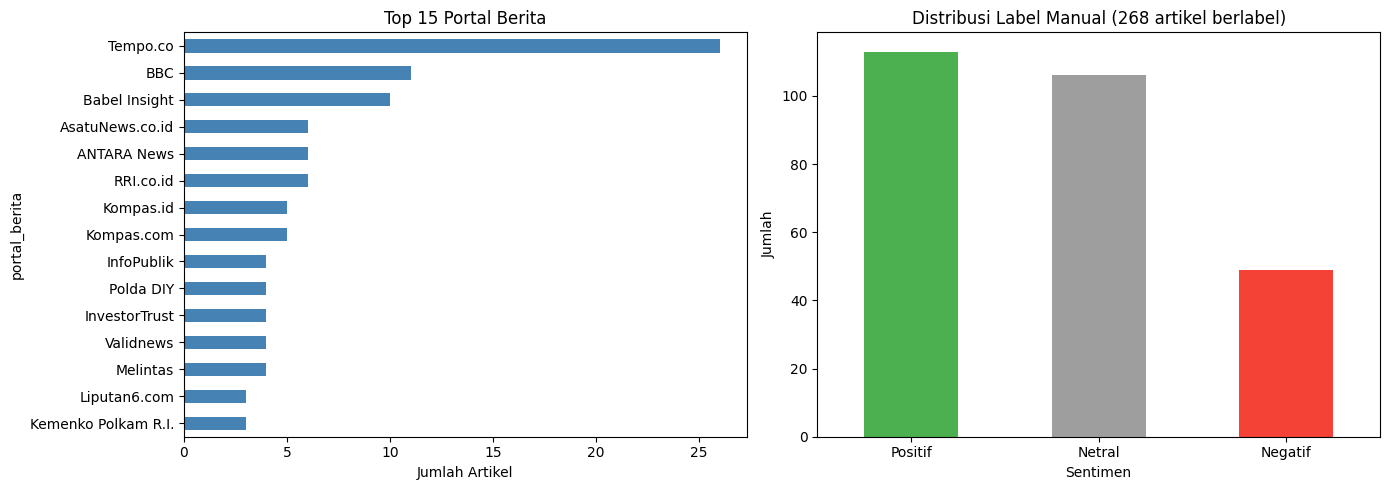

In [24]:
label_colors = {'Positif': '#4CAF50', 'Netral': '#9E9E9E', 'Negatif': '#F44336'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

portal_counts = df['portal_berita'].value_counts()
portal_counts.head(15).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Portal Berita')
axes[0].set_xlabel('Jumlah Artikel')
axes[0].invert_yaxis()

label_cnt = df['label'].value_counts()
colors_lbl = [label_colors.get(l, 'steelblue') for l in label_cnt.index]
label_cnt.plot(kind='bar', ax=axes[1], color=colors_lbl)
axes[1].set_title(f'Distribusi Label Manual ({len(df)} artikel berlabel)')
axes[1].set_xlabel('Sentimen')
axes[1].set_ylabel('Jumlah')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 5. Sentiment Analysis dengan IndoBERT

Model: [`apriandito/indobert-sentiment-classifier`](https://huggingface.co/apriandito/indobert-sentiment-classifier)

IndoBERT yang di-*fine-tune* untuk tiga kelas: `POSITIF`, `NETRAL`, `NEGATIF`.  
Input: **teks mentah artikel** (`konten`) yang dikondisikan dengan konteks topik.

In [25]:
MODEL_NAME = "apriandito/indobert-sentiment-classifier"
print(f"Loading: {MODEL_NAME}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model_sa  = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model_sa.to(torch_device)
model_sa.eval()

LABEL_IDX = {int(k): v for k, v in model_sa.config.id2label.items()}
LABEL_MAP  = {'POSITIF': 'Positif', 'NETRAL': 'Netral', 'NEGATIF': 'Negatif'}
print("Label mapping:", LABEL_IDX)
print("Model loaded.")

Loading: apriandito/indobert-sentiment-classifier


Loading weights: 100%|██████████| 393/393 [00:00<00:00, 7805.04it/s]


Label mapping: {0: 'NEGATIF', 1: 'NETRAL', 2: 'POSITIF'}
Model loaded.


In [26]:
CONTEXT = "Program Makan Bergizi Gratis"

def predict_sentiment(texts, batch_size=16):
    """Inference with context-conditioned input: [CLS] context [SEP] text [SEP]."""
    results = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Predicting"):
        batch = texts[i : i + batch_size]
        batch = [t if isinstance(t, str) and len(t) > 0 else "tidak ada teks" for t in batch]
        encodings = tokenizer(
            [CONTEXT] * len(batch),
            batch,
            truncation=True,
            max_length=256,
            padding=True,
            return_tensors="pt",
        ).to(torch_device)
        with torch.no_grad():
            logits = model_sa(**encodings).logits
            probs  = torch.softmax(logits, dim=-1)
            preds  = torch.argmax(probs, dim=-1)
            scores = probs[range(len(batch)), preds]
        for pred, score in zip(preds.cpu().numpy(), scores.cpu().numpy()):
            results.append({"label": LABEL_IDX[int(pred)], "score": float(score)})
    return results

texts = (df['judul'].fillna('') + ' ' + df['konten'].fillna('')).tolist()
raw_preds = predict_sentiment(texts)

df['pred_label_raw'] = [p['label'] for p in raw_preds]
df['pred_score']     = [p['score'] for p in raw_preds]
df['pred_sentiment'] = df['pred_label_raw'].map(LABEL_MAP)

print("\nDistribusi prediksi sentimen:")
print(df['pred_sentiment'].value_counts())

Predicting: 100%|██████████| 17/17 [00:11<00:00,  1.47it/s]


Distribusi prediksi sentimen:
pred_sentiment
Netral     162
Positif     71
Negatif     35
Name: count, dtype: int64


### 6. Analisis Hasil Sentimen

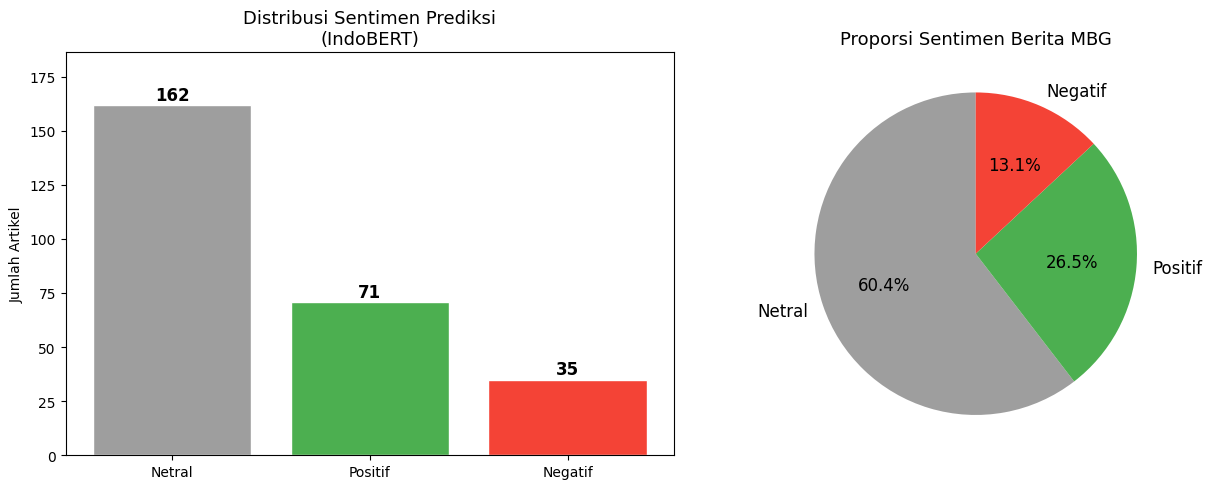

Netral    :  162 (60.4%)
Positif   :   71 (26.5%)
Negatif   :   35 (13.1%)


In [27]:
sentiment_classes = ['Positif', 'Netral', 'Negatif']
colors_map = {'Positif': '#4CAF50', 'Netral': '#9E9E9E', 'Negatif': '#F44336'}
sent_counts = df['pred_sentiment'].value_counts()
colors_sent = [colors_map.get(l, 'steelblue') for l in sent_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(sent_counts.index, sent_counts.values, color=colors_sent, edgecolor='white')
for bar, val in zip(bars, sent_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_title('Distribusi Sentimen Prediksi\n(IndoBERT)', fontsize=13)
axes[0].set_ylabel('Jumlah Artikel')
axes[0].set_ylim(0, sent_counts.max() * 1.15)

axes[1].pie(
    sent_counts.values, labels=sent_counts.index, colors=colors_sent,
    autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12},
)
axes[1].set_title('Proporsi Sentimen Berita MBG', fontsize=13)

plt.tight_layout()
plt.show()

total = len(df)
for s, c in sent_counts.items():
    print(f"{s:10s}: {c:4d} ({c / total * 100:.1f}%)")

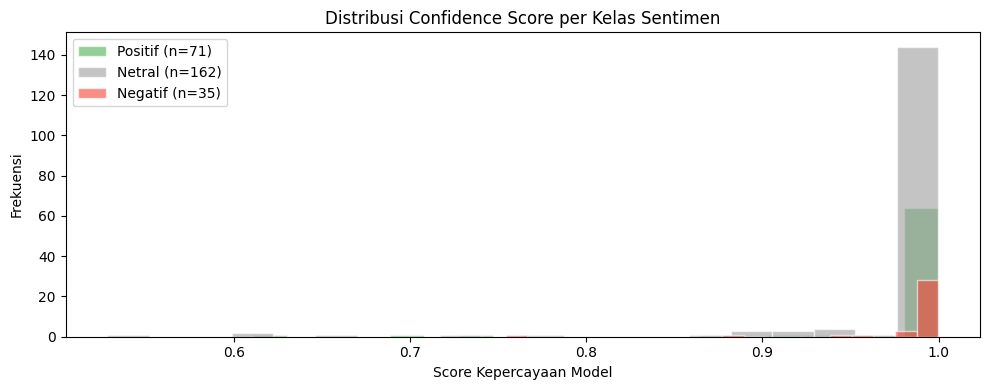

In [28]:
fig, ax = plt.subplots(figsize=(10, 4))
for sent in sentiment_classes:
    subset = df[df['pred_sentiment'] == sent]['pred_score']
    if len(subset) > 0:
        ax.hist(subset, bins=20, alpha=0.6, label=f'{sent} (n={len(subset)})',
                color=colors_map[sent], edgecolor='white')
ax.set_title('Distribusi Confidence Score per Kelas Sentimen')
ax.set_xlabel('Score Kepercayaan Model')
ax.set_ylabel('Frekuensi')
ax.legend()
plt.tight_layout()
plt.show()

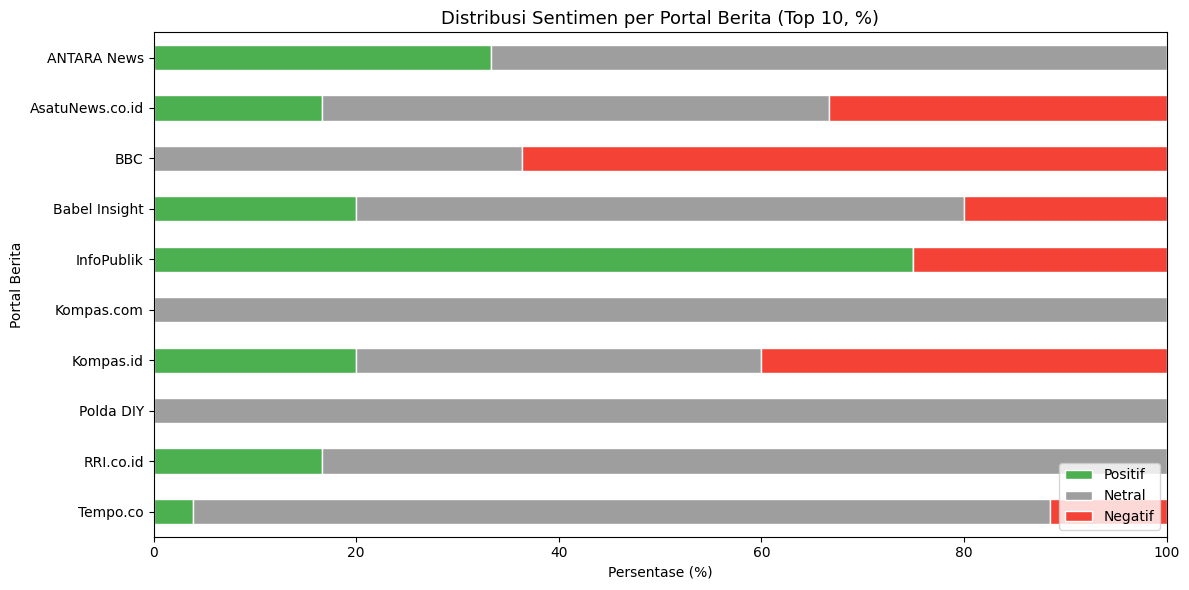

In [29]:
top_portals = df['portal_berita'].value_counts().head(10).index
df_top = df[df['portal_berita'].isin(top_portals)]

pivot = df_top.groupby(['portal_berita', 'pred_sentiment']).size().unstack(fill_value=0)
for col in ['Positif', 'Netral', 'Negatif']:
    if col not in pivot.columns:
        pivot[col] = 0
pivot = pivot[['Positif', 'Netral', 'Negatif']]
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))
pivot_pct.plot(
    kind='barh', stacked=True,
    color=[colors_map['Positif'], colors_map['Netral'], colors_map['Negatif']],
    ax=ax, edgecolor='white',
)
ax.set_title('Distribusi Sentimen per Portal Berita (Top 10, %)', fontsize=13)
ax.set_xlabel('Persentase (%)')
ax.set_ylabel('Portal Berita')
ax.legend(loc='lower right')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 7. Evaluasi terhadap Label Manual

Classification Report — IndoBERT
              precision    recall  f1-score   support

     Positif       0.93      0.58      0.72       113
      Netral       0.59      0.91      0.72       106
     Negatif       0.77      0.55      0.64        49

    accuracy                           0.71       268
   macro avg       0.76      0.68      0.69       268
weighted avg       0.77      0.71      0.70       268



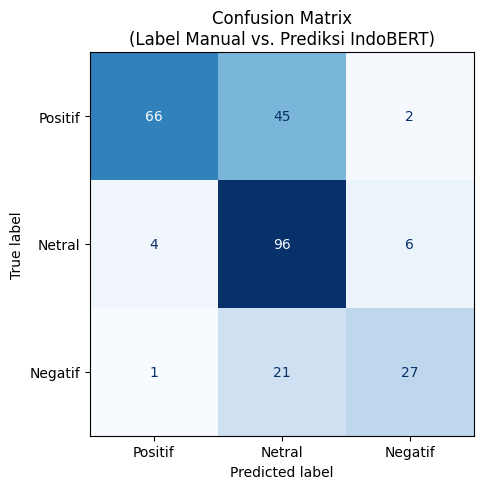

In [30]:
labels_order = ['Positif', 'Netral', 'Negatif']
y_true = df['label'].tolist()
y_pred = df['pred_sentiment'].tolist()

print("=" * 50)
print("Classification Report — IndoBERT")
print("=" * 50)
print(classification_report(y_true, y_pred, labels=labels_order, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=labels_order)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix\n(Label Manual vs. Prediksi IndoBERT)')
plt.tight_layout()
plt.show()

### 8. Word Cloud per Kelas Sentimen

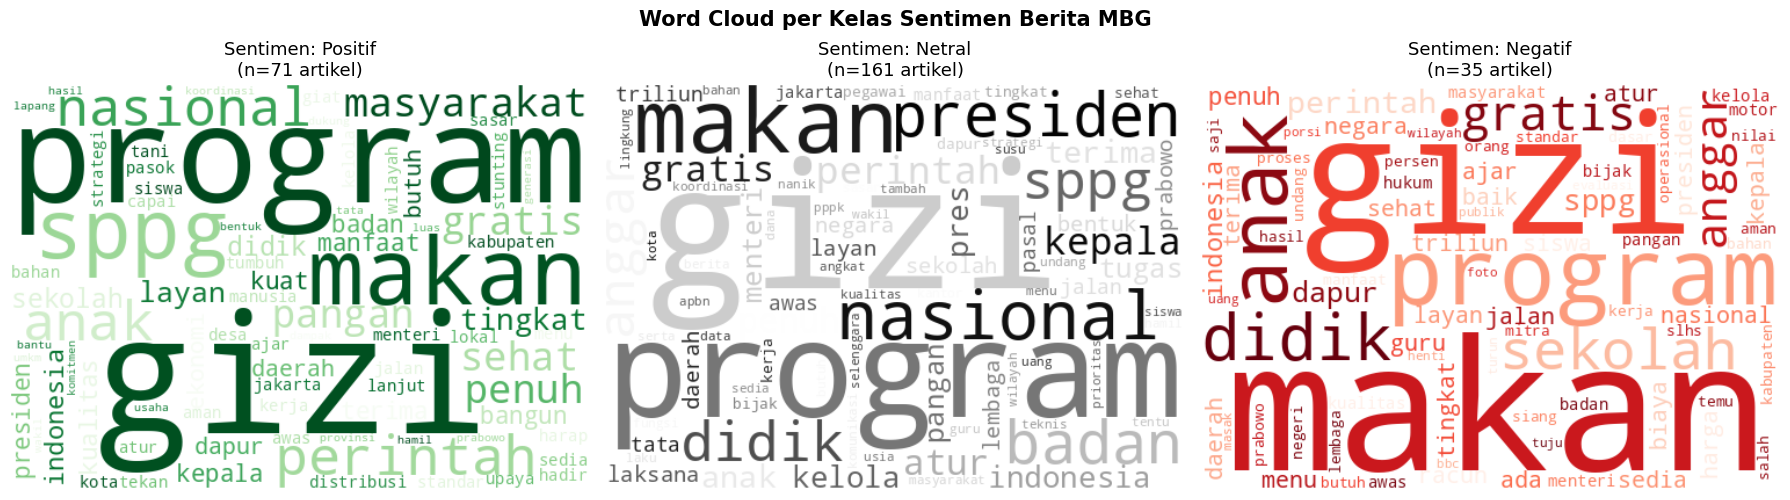

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
wc_colors = {'Positif': 'Greens', 'Netral': 'Greys', 'Negatif': 'Reds'}

for ax, sent in zip(axes, sentiment_classes):
    subset = df[df['pred_sentiment'] == sent]['after_lemmatization'].dropna()
    combined_text = ' '.join(subset.tolist())
    if not combined_text.strip():
        ax.text(0.5, 0.5, f'Tidak ada artikel {sent}', ha='center', va='center')
        ax.set_title(sent)
        ax.axis('off')
        continue
    wc = WordCloud(
        width=500, height=350, background_color='white',
        colormap=wc_colors[sent], max_words=80, collocations=False,
    ).generate(combined_text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Sentimen: {sent}\n(n={len(subset)} artikel)', fontsize=13)
    ax.axis('off')

plt.suptitle('Word Cloud per Kelas Sentimen Berita MBG', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 9. Top Artikel per Kelas Sentimen

In [32]:
for sent in sentiment_classes:
    subset = df[df['pred_sentiment'] == sent].nlargest(5, 'pred_score')
    if len(subset) == 0:
        continue
    print(f"\n{'=' * 60}")
    print(f"TOP 5 — {sent} (confidence tertinggi)")
    print('=' * 60)
    for _, row in subset.iterrows():
        title  = str(row['judul'])[:80]
        portal = str(row['portal_berita'])
        score  = row['pred_score']
        print(f"  [{score:.3f}] {title}")
        print(f"          Portal: {portal}")
        print()


TOP 5 — Positif (confidence tertinggi)
  [1.000] Ratusan Siswa MTsN 17 Jakarta Antusias Sambut Hari Pertama Program Makan Bergizi
          Portal: Jakarta Kemenag

  [1.000] KEMENTERIAN KOORDINATOR BIDANG PEREKONOMIAN REPUBLIK INDONESIA - - Kementerian K
          Portal: - Kementerian Koordinator Bidang Perekonomian Republik Indonesia

  [1.000] SPPG Jakut Kelapa Gading Pegangsaan Dua 2 Raih Predikat Dapur Terbaik dari Badan
          Portal: DIVISI HUMAS POLRI

  [1.000] Program Makan Bergizi Gratis adalah pengungkit yang efektif untuk Percepatan dan
          Portal: Tim Percepatan Penurunan Stunting

  [1.000] Mewujudkan Indonesia Sehat: Implementasi Program Makanan Bergizi Gratis di Tebin
          Portal: Pemerintah Kota Tebing Tinggi


TOP 5 — Netral (confidence tertinggi)
  [1.000] Profil Dadan Hindayana, Dosen IPB yang Dilantik Jokowi Jadi Kepala Badan Gizi Na
          Portal: Tempo.co

  [1.000] Prabowo Mau Bikin 3 Badan Baru di Pemerintahan Mendatang, Apa Saja? - Tempo.co

### 10. Analisis Kata Kunci per Sentimen (TF-IDF)

Menggunakan TF-IDF untuk menemukan kata yang paling membedakan setiap kelas sentimen.

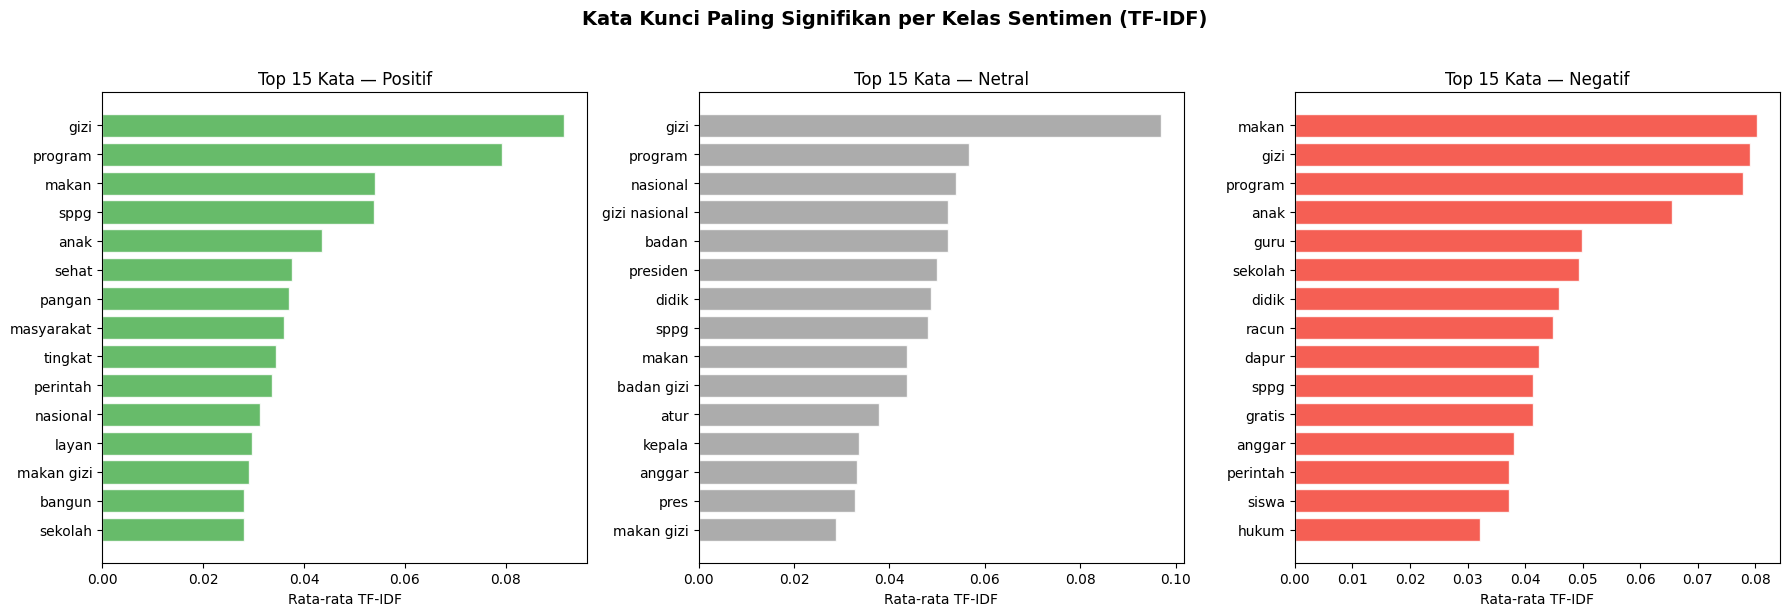

In [33]:
all_texts_sa = df['after_lemmatization'].fillna('').tolist()
tfidf_sa = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
tfidf_sa.fit(all_texts_sa)
feature_names_sa = tfidf_sa.get_feature_names_out()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, sent in zip(axes, sentiment_classes):
    corpus_sent = df[df['pred_sentiment'] == sent]['after_lemmatization'].fillna('').tolist()
    if not corpus_sent:
        ax.text(0.5, 0.5, 'Tidak ada artikel', ha='center', va='center')
        ax.set_title(sent)
        continue
    X = tfidf_sa.transform(corpus_sent)
    mean_tfidf = X.mean(axis=0).A1
    top_idx    = mean_tfidf.argsort()[-15:][::-1]
    top_words  = [feature_names_sa[i] for i in top_idx]
    top_scores = [mean_tfidf[i] for i in top_idx]
    ax.barh(range(len(top_words)), top_scores[::-1],
            color=colors_map[sent], edgecolor='white', alpha=0.85)
    ax.set_yticks(range(len(top_words)))
    ax.set_yticklabels(top_words[::-1], fontsize=10)
    ax.set_title(f'Top 15 Kata — {sent}', fontsize=12)
    ax.set_xlabel('Rata-rata TF-IDF')

plt.suptitle('Kata Kunci Paling Signifikan per Kelas Sentimen (TF-IDF)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 11. Simpan Hasil

In [34]:
output_cols = ['judul', 'link', 'portal_berita', 'pred_sentiment', 'pred_score',
               'label', 'after_lemmatization']
df_out = df[output_cols].rename(columns={
    'pred_sentiment'     : 'sentimen_prediksi',
    'pred_score'         : 'confidence',
    'label'              : 'label_manual',
    'after_lemmatization': 'text_berita_clean',
})

out_path = 'output/sentiment_results.csv'
df_out.to_csv(out_path, index=False)
print(f"Saved -> {out_path}  ({len(df_out)} rows)")
df_out.head()

Saved -> output/sentiment_results.csv  (268 rows)


,judul,link,portal_berita,sentimen_prediksi,confidence,label_manual,text_berita_clean
0,Viral Siswa SMP di Deli Serdang Buang MBG ke J...,https://www.liputan6.com/regional/read/6327490...,Liputan6.com,Negatif,0.999762,Negatif,liput com deli serdang aksi protes siswa siswi...
1,Sinergi Intelijen Lintas Sektoral Perkuat Pela...,https://polkam.go.id/sinergi-intelijen-lintas-...,Kemenko Polkam R.I.,Positif,0.997753,Positif,siar pers sp hm polkam polkam semarang konkret...
2,MBG dan Matinya Logika - Kompas.id,https://www.kompas.id/artikel/mbg-dan-matinya-...,Kompas.id,Positif,0.923384,Negatif,luar korupsi dll sy rakyat jelata yg untung ha...
3,Makan Bergizi Gratis (MBG) Bukan Sekadar Panga...,https://balitribune.co.id/content/makan-bergiz...,balitribune.co.id,Positif,0.999458,Positif,balitribune co id denpasar program makan gizi ...
4,"MBG: Bukan Sekadar Makan Gratis, Tapi Kurikulu...",https://pwmu.co/mbg-bukan-sekadar-makan-gratis...,PWMU.CO,Netral,0.884610,Positif,bagi program makan gizi gratis rambah sekolah ...


### 12. Ringkasan

| Aspek | Detail |
|---|---|
| **Dataset** | 599 berita MBG hasil scraping (Midterm) |
| **Model** | `apriandito/indobert-sentiment-classifier` (IndoBERT fine-tuned) |
| **Input** | Teks mentah artikel (`konten`) + konteks topik *"Program Makan Bergizi Gratis"* |
| **Kelas** | Positif / Netral / Negatif |
| **Evaluasi** | Dibandingkan dengan label manual hasil anotasi tim |

**Interpretasi kelas:**
- **Positif**: Artikel yang meliput capaian, dukungan, atau dampak positif program MBG
- **Netral**: Artikel bersifat informatif/deskriptif tanpa opini kuat
- **Negatif**: Artikel yang meliput kritik, kegagalan implementasi, atau kontroversi MBG

## TF-IDF Analysis

Section ini **independen** — membaca langsung dari `output/articles_preprocessed.csv`.

Analisis TF-IDF dilakukan berdasarkan:
1. **Kanal Berita** (sumber)
2. **Time Frame** (bulan/kuartal)
3. **Tipe Dokumen** (keyword)
4. **POS Analysis** (Noun, Verb, Adjective)
5. **NER Analysis** (entitas bernama)
6. **N-Grams** (bigram, trigram)

### Import Library & Load Data

In [35]:
import pandas as pd
import numpy as np
import re
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

# Load preprocessed dataset
df = pd.read_csv('output/articles_preprocessed.csv')
df['after_lemmatization'] = df['after_lemmatization'].fillna('')
df['konten'] = df['konten'].fillna('')

print(f'Loaded {len(df)} articles')
print(f'Keywords  : {df["keyword"].unique().tolist()}')
print(f'Sources   : {df["sumber"].nunique()} unique sources')
df.head(3)

Loaded 711 articles
Keywords  : ['Makan Bergizi Gratis', 'Makan Siang Gratis', 'MBG', 'Program Makan Gratis Pemerintah', 'Badan Gizi Nasional', 'Satuan Pelayanan Pemenuhan Gizi', 'SPPG', 'Perpres Nomor 83 Tahun 2024', 'Perpres Nomor 115 Tahun 2025']
Sources   : 343 unique sources


,keyword,judul,tanggal,sumber,source_url,url_google,url_resolved,konten,authors,to_lowercase,before_stopwords,n_before_stopwords,after_stopwords,n_after_stopwords,after_lemmatization
0,Makan Bergizi Gratis,Andi Gani: Yang Teriak MBG Tak Bermanfaat Depa...,"Mon, 04 May 2026 13:57:14 GMT",CNN Indonesia,https://www.cnnindonesia.com,https://news.google.com/rss/articles/CBMiywFBV...,https://www.cnnindonesia.com/nasional/20260504...,Ketua Panitia May Day 2026 sekaligus Presiden ...,NaN,ketua panitia may day 2026 sekaligus presiden ...,ketua panitia may day sekaligus presiden konfe...,260,ketua panitia may day presiden konfederasi ser...,133,ketua panitia may day presiden konfederasi ser...
1,Makan Bergizi Gratis,Konsolidasi Bersama Badan Gizi Nasional dan Gu...,"Mon, 04 May 2026 11:26:00 GMT",Polri,https://mediahub.polri.go.id,https://news.google.com/rss/articles/CBMi4AFBV...,https://mediahub.polri.go.id/in/image/detail/4...,Diunggah OlehMABES POLRI\n| Diupdate pada 5/05...,NaN,diunggah olehmabes polri\n| diupdate pada 5/05...,diunggah olehmabes polri diupdate pada wib kre...,433,diunggah olehmabes polri diupdate wib kreator ...,263,unggah olehmabes polri diupdate wib kreator op...
2,Makan Bergizi Gratis,Mengapa Dapur MBG Bisa Beroperasi Tanpa Memenu...,"Tue, 05 May 2026 01:00:00 GMT",Tempo.co,https://koran.tempo.co,https://news.google.com/rss/articles/CBMinAFBV...,https://www.tempo.co/politik/limbah-dapur-mbg-...,BADAN Gizi Nasional (BGN) memberikan sanksi pe...,NaN,badan gizi nasional (bgn) memberikan sanksi pe...,badan gizi nasional bgn memberikan sanksi peny...,44,badan gizi nasional sanksi penyetopan operasi ...,28,badan gizi nasional sanksi setop operasi layan...


In [36]:
def tfidf_per_group(df, text_col, group_col, top_n=10, ngram_range=(1,1)):
    """
    Group documents by group_col, concatenate text per group,
    apply TF-IDF across groups, return top_n words per group.
    """
    groups = (
        df.groupby(group_col)[text_col]
        .apply(lambda texts: ' '.join(texts.fillna('')))
    )
    labels = groups.index.tolist()
    docs   = groups.tolist()

    pairs = [(l, d) for l, d in zip(labels, docs) if d.strip()]
    if not pairs:
        return pd.DataFrame()
    labels, docs = zip(*pairs)

    vectorizer = TfidfVectorizer(ngram_range=ngram_range)
    tfidf_matrix = vectorizer.fit_transform(docs)
    features = vectorizer.get_feature_names_out()

    rows = []
    for i, label in enumerate(labels):
        scores = tfidf_matrix[i].toarray().flatten()
        top_idx = scores.argsort()[::-1][:top_n]
        for rank, idx in enumerate(top_idx, 1):
            if scores[idx] > 0:
                rows.append({
                    group_col: label,
                    'rank': rank,
                    'term': features[idx],
                    'tfidf': round(float(scores[idx]), 4)
                })
    return pd.DataFrame(rows)


def show_top_words(df_result, group_col, title=''):
    """
    Pivot TF-IDF result into a wide table.
    Rows = rank, Columns = group, Values = top word at that rank.
    """
    if df_result.empty:
        print('No results.')
        return
    pivot = df_result.pivot_table(
        index='rank', columns=group_col,
        values='term', aggfunc='first'
    )
    if title:
        print(f'=== {title} ===')
    print(
        '\n📊 Cara membaca tabel ini:'
        f'\n   Kolom  → setiap kelompok ({group_col})'
        '\n   Baris  → peringkat kata (rank 1 = kata paling khas/distingtif)'
        '\n   Nilai  → kata dengan skor TF-IDF tertinggi untuk kelompok tersebut'
        '\n   ⚡ Kata di rank 1 adalah yang PALING MEMBEDAKAN kelompok itu dari kelompok lain.'
        '\n   ℹ️  TF-IDF tinggi = kata sering muncul di grup ini, tapi jarang di grup lain.\n'
    )
    display(pivot)


print('Helper functions ready.')


Helper functions ready.


---
### 1. TF-IDF by Kanal Berita (Sumber)

Mengelompokkan artikel berdasarkan sumber berita, lalu mencari kata dengan skor TF-IDF tertinggi per sumber.
Kata dengan skor tinggi = kata yang **khas** untuk sumber tersebut, bukan sekadar kata umum di seluruh corpus.

In [37]:
# How many articles per source?
sumber_counts = df['sumber'].value_counts()
print('Articles per source:')
print(sumber_counts.to_string())

Articles per source:
sumber
Tempo.co                                                            38
RRI.co.id                                                           34
ANTARA News                                                         24
Babel Insight                                                       20
AsatuNews.co.id                                                     19
BBC                                                                 14
Kompas.com                                                          13
DIVISI HUMAS POLRI                                                   9
Media Indonesia                                                      8
Kompas.id                                                            8
InvestorTrust                                                        8
CNN Indonesia                                                        7
Liputan6.com                                                         7
Berita Cilegon                                   

In [38]:
# Use sources with >= 2 articles for meaningful TF-IDF
valid_sumber = sumber_counts[sumber_counts >= 2].index.tolist()
df_kanal = df[df['sumber'].isin(valid_sumber)]

result_kanal = tfidf_per_group(df_kanal, 'after_lemmatization', 'sumber', top_n=10)
show_top_words(result_kanal, 'sumber', 'Top 10 TF-IDF Words per Kanal Berita')

=== Top 10 TF-IDF Words per Kanal Berita ===

📊 Cara membaca tabel ini:
   Kolom  → setiap kelompok (sumber)
   Baris  → peringkat kata (rank 1 = kata paling khas/distingtif)
   Nilai  → kata dengan skor TF-IDF tertinggi untuk kelompok tersebut
   ⚡ Kata di rank 1 adalah yang PALING MEMBEDAKAN kelompok itu dari kelompok lain.
   ℹ️  TF-IDF tinggi = kata sering muncul di grup ini, tapi jarang di grup lain.



sumber,ANTARA News,ANTARA News Jateng,ANTARA News Papua Tengah,ANTARA News Sulteng,Aktual.com,Antara News jatim,Arsip Nasional Republik Indonesia,AsatuNews.co.id,BBC,Babel Insight,...,fraksi gerindra dpr-ri,gesuri.id,insidelombok,jatimnow.com,kontan.co.id,magetan.go.id,mpr.go.id,nusantaratv.com,pesisirbaratkab.go.id,tribratanews-polrescirebon.com
rank,,,,,,,,,,,,,,,,,,,,,
1,gizi,blora,mimika,palu,uu,timur,arsip,gizi,makan,buruh,...,yuliansyah,deddy,lombok,kampus,pppk,about,eddy,nusantaratv,pesisir,cirebon
2,nasional,polres,nabire,ikra,hukum,kiri,kelola,program,bbc,gizi,...,program,pdi,bunut,jatimnow,pegawai,wordpress,mpr,nanik,barat,gegesik
3,badan,sppg,papua,program,kemendagri,kanan,bimtek,doni,gizi,program,...,hergun,juang,baok,gizi,gaji,troubleshooting,program,dapur,pekon,kemantren
4,atur,karangjati,sppg,sma,bima,jawa,program,dudung,lansia,kepala,...,gizi,jokowi,tinggal,dony,angkat,error,ibas,com,pesisirbaratkab,giat
5,crawling,batang,program,miskin,atur,tulungagung,gizi,kampus,program,lansir,...,makan,kritik,hasil,bilbina,gizi,been,karanglo,bahan,rawas,polsek
6,kirimkomentar,manfaat,wilayah,sulteng,niat,jatim,anri,buruh,anggar,nasional,...,sukabumi,honorer,inside,arzeti,rapbn,has,ponorogo,bupati,website,kapolsek
7,uu,terima,mandenas,siswa,daerah,slhs,andi,operasional,foto,dudung,...,kunjung,desak,hipmi,ulul,didik,learn,gizi,pangan,sppg,camat
8,program,layan,evarianus,makan,undang,sppg,naskah,ya,harga,data,...,pontianak,sonny,ihsan,henti,atur,more,makan,kepala,lampung,akp
9,keras,gizi,suparcopyright,tara,pres,rapat,tertib,sppg,anak,presiden,...,fraksigerindra,falah,tunggu,mati,sppg,this,ifsr,sppg,adu,patroli


#### 💡 Interpretasi: TF-IDF per Kanal Berita

**Cara membaca tabel:**
- Setiap **kolom** mewakili satu sumber berita (kanal)
- Setiap **baris** adalah peringkat — rank 1 = kata paling khas untuk sumber itu
- **Kata dengan skor TF-IDF tinggi** = kata yang sering muncul di sumber ini tapi **jarang** di sumber lain

**Contoh interpretasi:**
Jika Kompas.com memiliki kata `"kebijakan"` di rank 1, artinya Kompas.com lebih banyak
membahas aspek kebijakan MBG dibandingkan sumber berita lain dalam corpus ini.

> ℹ️ Sumber dengan hanya 1 artikel diexclude karena TF-IDF membutuhkan
> perbandingan antar-dokumen untuk bermakna.

In [39]:
# Detailed score table for all sources
print('=== TF-IDF Scores per Kanal Berita (Full Table) ===')
display(result_kanal.sort_values(['sumber', 'rank']))

=== TF-IDF Scores per Kanal Berita (Full Table) ===


,sumber,rank,term,tfidf
0,ANTARA News,1,gizi,0.3198
1,ANTARA News,2,nasional,0.2131
2,ANTARA News,3,badan,0.1789
3,ANTARA News,4,atur,0.1706
4,ANTARA News,5,crawling,0.1660
...,...,...,...,...
1012,tribratanews-polrescirebon.com,6,kapolsek,0.1622
1013,tribratanews-polrescirebon.com,7,camat,0.1329
1014,tribratanews-polrescirebon.com,8,akp,0.1266
1015,tribratanews-polrescirebon.com,9,patroli,0.1209


---
### 2. TF-IDF by Time Frame (Bulan / Kuartal)

Mengelompokkan artikel berdasarkan waktu publikasi untuk melihat bagaimana topik berkembang dari waktu ke waktu.

In [40]:
# Parse publication date
df['tanggal_parsed'] = pd.to_datetime(
    df['tanggal'], format='%a, %d %b %Y %H:%M:%S %Z', errors='coerce'
)
df['bulan']   = df['tanggal_parsed'].dt.to_period('M').astype(str)
df['kuartal'] = df['tanggal_parsed'].dt.to_period('Q').astype(str)

print('Distribution by Month:')
print(df['bulan'].value_counts().sort_index())
print('\nDistribution by Quarter:')
print(df['kuartal'].value_counts().sort_index())

Distribution by Month:
bulan
2023-12      1
2024-02      3
2024-03      1
2024-08     43
2024-09      5
2024-11     11
2024-12      6
2025-01     26
2025-02      6
2025-03      1
2025-04      7
2025-05      1
2025-06      3
2025-07      9
2025-08      5
2025-09     10
2025-10     16
2025-11     19
2025-12     12
2026-01     73
2026-02     40
2026-03     40
2026-04     94
2026-05    279
Name: count, dtype: int64

Distribution by Quarter:
kuartal
2023Q4      1
2024Q1      4
2024Q3     48
2024Q4     17
2025Q1     33
2025Q2     11
2025Q3     24
2025Q4     47
2026Q1    153
2026Q2    373
Name: count, dtype: int64


In [41]:
# TF-IDF by Month
df_time = df.dropna(subset=['bulan'])
result_bulan = tfidf_per_group(df_time, 'after_lemmatization', 'bulan', top_n=10)
show_top_words(result_bulan, 'bulan', 'Top 10 TF-IDF Words per Bulan')

=== Top 10 TF-IDF Words per Bulan ===

📊 Cara membaca tabel ini:
   Kolom  → setiap kelompok (bulan)
   Baris  → peringkat kata (rank 1 = kata paling khas/distingtif)
   Nilai  → kata dengan skor TF-IDF tertinggi untuk kelompok tersebut
   ⚡ Kata di rank 1 adalah yang PALING MEMBEDAKAN kelompok itu dari kelompok lain.
   ℹ️  TF-IDF tinggi = kata sering muncul di grup ini, tapi jarang di grup lain.



bulan,2023-12,2024-02,2024-03,2024-08,2024-09,2024-11,2024-12,2025-01,2025-02,2025-03,...,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05
rank,,,,,,,,,,,,,,,,,,,,,
1,makan,program,program,gizi,pekanbaru,gizi,makan,gizi,program,gizi,...,didik,gizi,gizi,gizi,program,sppg,sppg,sppg,gizi,pinjam
2,program,makan,ssfp,nasional,badan,makan,gizi,makan,gizi,makan,...,makan,program,program,program,gizi,gizi,gizi,gizi,sppg,batal
3,anak,siang,malaysia,badan,gizi,program,harga,program,makan,didik,...,sekolah,didik,makan,makan,sppg,program,program,program,program,spinjam
4,sekolah,said,makan,presiden,gizinasional,gratis,lauk,anggar,anak,gratis,...,gizi,makan,perintah,perintah,makan,pegawai,makan,makan,ada,shopee
5,negara,gratis,hmsp,didik,makan,china,porsi,gratis,indonesia,posyandu,...,program,anak,atur,anak,rambipuji,makan,didik,dapur,makan,cs
6,terima,butuh,singapura,tugas,risnandar,lanud,program,triliun,perintah,anak,...,atur,sehat,undang,gratis,perintah,pppk,layan,penuh,anggar,customer
7,dapat,bar,perintah,kepala,simulasi,nasional,nasi,perintah,menteri,kategori,...,dasar,gratis,anak,pangan,penuh,perintah,anak,pppk,nasional,ktp
8,manfaat,esther,anak,penuh,karbon,perintah,anak,nasional,india,skema,...,manfaat,entomologi,racun,sppg,masyarakat,atur,perintah,nanik,motor,service
9,asia,pangan,supplementary,bentuk,ferry,pinjam,anggar,sekolah,anggar,terima,...,kota,tebing,gratis,daerah,pangan,terima,anggar,layan,kepala,program


#### 💡 Interpretasi: TF-IDF per Bulan

- Setiap **kolom** = bulan publikasi (format: YYYY-MM)
- Setiap **baris** = peringkat kata khas untuk bulan tersebut
- Kata yang muncul di rank atas suatu bulan artinya topik/isu tersebut **sedang ramai dibicarakan** di bulan itu

**Gunanya untuk:** melihat **evolusi isu** — apakah kata kunci berubah seiring waktu?
Misalnya, bulan awal mungkin banyak bicara `"peluncuran"`, bulan berikutnya `"keracunan"` atau `"efisiensi"`.

In [42]:
# TF-IDF by Quarter
result_kuartal = tfidf_per_group(df_time, 'after_lemmatization', 'kuartal', top_n=10)
show_top_words(result_kuartal, 'kuartal', 'Top 10 TF-IDF Words per Kuartal')

=== Top 10 TF-IDF Words per Kuartal ===

📊 Cara membaca tabel ini:
   Kolom  → setiap kelompok (kuartal)
   Baris  → peringkat kata (rank 1 = kata paling khas/distingtif)
   Nilai  → kata dengan skor TF-IDF tertinggi untuk kelompok tersebut
   ⚡ Kata di rank 1 adalah yang PALING MEMBEDAKAN kelompok itu dari kelompok lain.
   ℹ️  TF-IDF tinggi = kata sering muncul di grup ini, tapi jarang di grup lain.



kuartal,2023Q4,2024Q1,2024Q3,2024Q4,2025Q1,2025Q2,2025Q3,2025Q4,2026Q1,2026Q2
rank,,,,,,,,,,
1,program,program,gizi,gizi,gizi,presiden,gizi,program,sppg,pinjam
2,makan,makan,nasional,makan,program,komunikasi,program,gizi,gizi,batal
3,anak,siang,badan,program,makan,makan,makan,makan,program,spinjam
4,sekolah,gratis,presiden,gratis,gratis,kantor,didik,perintah,makan,shopee
5,negara,indonesia,didik,anak,anggar,windu,sekolah,anak,pegawai,program
6,terima,said,kepala,perintah,perintah,pasal,anak,sppg,layan,gizi
7,manfaat,butuh,tugas,indonesia,triliun,anak,perintah,atur,penuh,sppg
8,dapat,pangan,bentuk,nasional,anak,program,nasional,gratis,perintah,cs
9,programs,perintah,penuh,harga,nasional,strategis,gratis,sekolah,pppk,customer


#### 💡 Interpretasi: TF-IDF per Kuartal

Sama seperti per bulan, namun dengan granularitas **kuartalan** (Q1 = Jan-Mar, Q2 = Apr-Jun, dst.).
Berguna jika data tidak merata per bulan — menghindari bias akibat bulan dengan terlalu sedikit artikel.

---
### 3. TF-IDF by Keyword (Tipe Dokumen)

Setiap artikel dikumpulkan menggunakan keyword tertentu (e.g. 'MBG', 'Badan Gizi Nasional', dll.).
TF-IDF per keyword menunjukkan kata yang **paling khas** untuk setiap topik pencarian.

In [43]:
print('Articles per keyword:')
print(df['keyword'].value_counts())

Articles per keyword:
keyword
Makan Bergizi Gratis               96
Perpres Nomor 83 Tahun 2024        94
Perpres Nomor 115 Tahun 2025       83
Satuan Pelayanan Pemenuhan Gizi    78
Program Makan Gratis Pemerintah    77
Badan Gizi Nasional                77
MBG                                75
Makan Siang Gratis                 68
SPPG                               63
Name: count, dtype: int64


In [44]:
result_kw = tfidf_per_group(df, 'after_lemmatization', 'keyword', top_n=10)
show_top_words(result_kw, 'keyword', 'Top 10 TF-IDF Words per Keyword')

=== Top 10 TF-IDF Words per Keyword ===

📊 Cara membaca tabel ini:
   Kolom  → setiap kelompok (keyword)
   Baris  → peringkat kata (rank 1 = kata paling khas/distingtif)
   Nilai  → kata dengan skor TF-IDF tertinggi untuk kelompok tersebut
   ⚡ Kata di rank 1 adalah yang PALING MEMBEDAKAN kelompok itu dari kelompok lain.
   ℹ️  TF-IDF tinggi = kata sering muncul di grup ini, tapi jarang di grup lain.



keyword,Badan Gizi Nasional,MBG,Makan Bergizi Gratis,Makan Siang Gratis,Perpres Nomor 115 Tahun 2025,Perpres Nomor 83 Tahun 2024,Program Makan Gratis Pemerintah,SPPG,Satuan Pelayanan Pemenuhan Gizi
rank,,,,,,,,,
1,gizi,program,program,makan,gizi,gizi,program,pinjam,sppg
2,program,gizi,gizi,program,sppg,nasional,gizi,batal,gizi
3,sppg,sppg,makan,gizi,program,badan,makan,spinjam,program
4,ada,makan,gratis,gratis,pppk,presiden,perintah,shopee,layan
5,makan,dapur,nasional,anak,pegawai,program,didik,cs,penuh
6,nasional,perintah,dapur,sekolah,angkat,atur,anak,customer,makan
7,anggar,masyarakat,masyarakat,anggar,atur,pres,sppg,service,dapur
8,badan,manfaat,sppg,perintah,pres,makan,gratis,ktp,masyarakat
9,motor,anak,dudung,didik,makan,didik,sehat,chat,perintah


#### 💡 Interpretasi: TF-IDF per Keyword

Setiap artikel dikumpulkan menggunakan keyword pencarian tertentu.
TF-IDF per keyword menunjukkan **kata yang paling membedakan** artikel dari keyword A vs keyword B.

- Jika keyword `"Perpres Nomor 83 Tahun 2024"` punya kata `"peraturan"` di rank 1,
  berarti artikel dari keyword itu lebih legal/formal dibanding keyword lain.
- Berguna untuk melihat apakah setiap keyword benar-benar menghasilkan konten yang **berbeda subtopiknya**.

In [45]:
# Full score table
display(result_kw.sort_values(['keyword', 'rank']))

,keyword,rank,term,tfidf
0,Badan Gizi Nasional,1,gizi,0.4097
1,Badan Gizi Nasional,2,program,0.2782
2,Badan Gizi Nasional,3,sppg,0.2445
3,Badan Gizi Nasional,4,ada,0.1988
4,Badan Gizi Nasional,5,makan,0.1988
...,...,...,...,...
85,Satuan Pelayanan Pemenuhan Gizi,6,makan,0.1919
86,Satuan Pelayanan Pemenuhan Gizi,7,dapur,0.1437
87,Satuan Pelayanan Pemenuhan Gizi,8,masyarakat,0.1437
88,Satuan Pelayanan Pemenuhan Gizi,9,perintah,0.1128


---
### 4. TF-IDF + POS Analysis

POS tagging menggunakan **Stanza** (model Bahasa Indonesia `id`).
Token difilter berdasarkan kategori Universal POS:
- **NOUN / PROPN** (kata benda & nama diri)
- **VERB** (kata kerja)
- **ADJ** (kata sifat)

> Install jika belum: `pip install stanza` lalu `python -c "import stanza; stanza.download('id')"`

In [46]:
import stanza
from transformers import pipeline, AutoTokenizer, AutoModelForTokenClassification

# ── Stanza: POS tagging only (NER not available for Indonesian in Stanza)
# Download once if needed: stanza.download('id')
nlp_stanza = stanza.Pipeline(
    lang='id',
    processors='tokenize,mwt,pos',
    verbose=False
)
print('Stanza pipeline loaded (id): tokenize, mwt, pos')

# ── Transformers: NER using IndoBERT
MODEL_NAME = 'cahya/bert-base-indonesian-NER'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
model      = AutoModelForTokenClassification.from_pretrained(MODEL_NAME)
ner_pipe   = pipeline(
    'ner',
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy='simple'
)
print(f'NER pipeline loaded: {MODEL_NAME}')

Stanza pipeline loaded (id): tokenize, mwt, pos


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 28006.12it/s]
BertForTokenClassification LOAD REPORT from: cahya/bert-base-indonesian-NER
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 
bert.pooler.dense.bias       | UNEXPECTED |  | 
bert.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


NER pipeline loaded: cahya/bert-base-indonesian-NER


In [47]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()


def extract_pos_tokens(text: str, upos_tags: list) -> str:
    """Extract & stem tokens whose Universal POS tag is in upos_tags."""
    if not isinstance(text, str) or not text.strip():
        return ''
    doc = nlp_stanza(text[:5000])  # limit length for speed
    tokens = [
        stemmer.stem(word.text.lower())
        for sent in doc.sentences
        for word in sent.words
        if word.upos in upos_tags
        and word.text.isalpha()
        and len(word.text) > 2
    ]
    return ' '.join(tokens)


print('Extracting POS tokens (Stanza)... may take a moment.')
df['pos_noun'] = df['konten'].apply(lambda t: extract_pos_tokens(t, ['NOUN', 'PROPN']))
df['pos_verb'] = df['konten'].apply(lambda t: extract_pos_tokens(t, ['VERB']))
df['pos_adj']  = df['konten'].apply(lambda t: extract_pos_tokens(t, ['ADJ']))
print('Done!')

# Quick sanity check
sample = df['pos_noun'].iloc[0].split()[:15]
print(f'\nSample NOUN tokens (row 0): {sample}')

Extracting POS tokens (Stanza)... may take a moment.
Done!

Sample NOUN tokens (row 0): ['ketua', 'panitia', 'may', 'day', 'presiden', 'konfederasi', 'serikat', 'kerja', 'indonesia', 'kspsi', 'andi', 'gani', 'nena', 'wea', 'video']


In [48]:
# TF-IDF on NOUN tokens, grouped by keyword
result_noun = tfidf_per_group(df, 'pos_noun', 'keyword', top_n=10)
show_top_words(result_noun, 'keyword', 'Top 10 TF-IDF NOUN per Keyword')

=== Top 10 TF-IDF NOUN per Keyword ===

📊 Cara membaca tabel ini:
   Kolom  → setiap kelompok (keyword)
   Baris  → peringkat kata (rank 1 = kata paling khas/distingtif)
   Nilai  → kata dengan skor TF-IDF tertinggi untuk kelompok tersebut
   ⚡ Kata di rank 1 adalah yang PALING MEMBEDAKAN kelompok itu dari kelompok lain.
   ℹ️  TF-IDF tinggi = kata sering muncul di grup ini, tapi jarang di grup lain.



keyword,Badan Gizi Nasional,MBG,Makan Bergizi Gratis,Makan Siang Gratis,Perpres Nomor 115 Tahun 2025,Perpres Nomor 83 Tahun 2024,Program Makan Gratis Pemerintah,SPPG,Satuan Pelayanan Pemenuhan Gizi
rank,,,,,,,,,
1,bgn,mbg,program,program,mbg,gizi,program,sppg,sppg
2,gizi,program,gizi,makan,gizi,badan,mbg,gizi,gizi
3,program,gizi,mbg,gizi,sppg,presiden,gizi,dapur,program
4,mbg,sppg,makan,mbg,program,nasional,makan,program,layan
5,sppg,makan,dapur,sekolah,tahun,program,perintah,mbg,makan
6,dad,perintah,masyarakat,anggar,pres,tahun,sppg,makan,penuh
7,makan,dapur,sppg,siang,pegawai,didik,gratis,layan,masyarakat
8,ada,masyarakat,dudung,perintah,pppk,pres,masyarakat,masyarakat,dapur
9,anggar,manfaat,gratis,siswa,makan,atur,laksana,penuh,satu


#### 💡 Interpretasi: TF-IDF NOUN

Tabel di atas hanya berisi **kata benda (NOUN/PROPN)** yang telah di-stem.
- Kata benda mencerminkan **objek, konsep, dan entitas utama** yang dibahas
- Contoh: `program`, `dapur`, `gizi`, `pelajar`, `anggaran`
- TF-IDF memastikan kata benda yang ditampilkan adalah yang **khas untuk keyword tersebut**, bukan kata benda umum yang muncul di semua artikel

In [49]:
# TF-IDF on VERB tokens, grouped by keyword
result_verb = tfidf_per_group(df, 'pos_verb', 'keyword', top_n=10)
show_top_words(result_verb, 'keyword', 'Top 10 TF-IDF VERB per Keyword')

=== Top 10 TF-IDF VERB per Keyword ===

📊 Cara membaca tabel ini:
   Kolom  → setiap kelompok (keyword)
   Baris  → peringkat kata (rank 1 = kata paling khas/distingtif)
   Nilai  → kata dengan skor TF-IDF tertinggi untuk kelompok tersebut
   ⚡ Kata di rank 1 adalah yang PALING MEMBEDAKAN kelompok itu dari kelompok lain.
   ℹ️  TF-IDF tinggi = kata sering muncul di grup ini, tapi jarang di grup lain.



keyword,Badan Gizi Nasional,MBG,Makan Bergizi Gratis,Makan Siang Gratis,Perpres Nomor 115 Tahun 2025,Perpres Nomor 83 Tahun 2024,Program Makan Gratis Pemerintah,SPPG,Satuan Pelayanan Pemenuhan Gizi
rank,,,,,,,,,
1,ada,jadi,jadi,ada,jadi,jadi,jadi,jadi,jadi
2,jadi,laku,ada,jadi,angkat,ada,ada,ada,ada
3,laku,ada,jalan,kata,ada,laku,jalan,laku,laku
4,kata,jalan,laku,makan,kata,bentuk,laku,kait,pasti
5,jalan,kata,pasti,gizi,masuk,laksana,pasti,jalan,jalan
6,pasti,pasti,nilai,beri,beri,atur,beri,beri,harap
7,beri,tingkat,beri,dapat,dapat,beri,rupa,ujar,beri
8,kait,nilai,ujar,laku,tegas,kata,tegas,operasi,hadir
9,masuk,kait,kata,tingkat,pasti,rupa,harap,harap,penuh


#### 💡 Interpretasi: TF-IDF VERB

Tabel berisi **kata kerja (VERB)** yang paling khas per keyword.
- Kata kerja mencerminkan **aksi dan proses** yang terjadi dalam pemberitaan
- Contoh: `membangun`, `menyalurkan`, `mengawasi`, `mengevaluasi`
- Berguna untuk memahami **framing berita**: apakah berita lebih banyak membahas tindakan pemerintah, reaksi masyarakat, atau proses teknis?

In [50]:
# TF-IDF on ADJ tokens, grouped by keyword
result_adj = tfidf_per_group(df, 'pos_adj', 'keyword', top_n=10)
show_top_words(result_adj, 'keyword', 'Top 10 TF-IDF ADJ per Keyword')

=== Top 10 TF-IDF ADJ per Keyword ===

📊 Cara membaca tabel ini:
   Kolom  → setiap kelompok (keyword)
   Baris  → peringkat kata (rank 1 = kata paling khas/distingtif)
   Nilai  → kata dengan skor TF-IDF tertinggi untuk kelompok tersebut
   ⚡ Kata di rank 1 adalah yang PALING MEMBEDAKAN kelompok itu dari kelompok lain.
   ℹ️  TF-IDF tinggi = kata sering muncul di grup ini, tapi jarang di grup lain.



keyword,Badan Gizi Nasional,MBG,Makan Bergizi Gratis,Makan Siang Gratis,Perpres Nomor 115 Tahun 2025,Perpres Nomor 83 Tahun 2024,Program Makan Gratis Pemerintah,SPPG,Satuan Pelayanan Pemenuhan Gizi
rank,,,,,,,,,
1,operasional,tinggi,langsung,gratis,lokal,nasional,nasional,baik,operasional
2,nasional,langsung,nasional,lain,lain,lain,langsung,operasional,baik
3,jelas,baik,penting,baik,kecil,baru,lain,lain,standar
4,besar,penting,awal,salah,hamil,strategis,lokal,langsung,sehat
5,lain,lokal,besar,pertama,jelas,gratis,salah,standar,utama
6,strategis,operasional,operasional,besar,penting,sama,hamil,lokal,langsung
7,resmi,strategis,salah,langsung,utama,khusus,baik,salah,aman
8,langsung,nasional,lain,awal,nasional,teknis,sama,tinggi,nyata
9,awal,besar,utama,sama,langsung,hamil,utama,penting,nasional


#### 💡 Interpretasi: TF-IDF ADJ

Tabel berisi **kata sifat (ADJ)** yang paling khas per keyword.
- Kata sifat mencerminkan **sentimen dan penilaian** dalam pemberitaan
- Contoh: `gratis`, `bergizi`, `optimal`, `bermasalah`, `efisien`
- Berguna untuk analisis **tone/framing**: apakah pemberitaan cenderung positif atau kritis?

---
### 5. TF-IDF + NER Analysis

NER menggunakan **`cahya/bert-base-indonesian-NER`** (IndoBERT fine-tuned untuk Indonesian NER).
Entity group yang dihasilkan model:
- **PER** — nama orang
- **ORG** — organisasi / lembaga
- **LOC** — lokasi / tempat
- **MISC** — entitas lain

In [51]:
def extract_ner_tokens(text: str, ent_types: list) -> str:
    """
    Extract named entities using cahya/bert-base-indonesian-NER.
    ner_pipe returns: [{'entity_group': 'PER', 'word': '...', ...}]
    """
    if not isinstance(text, str) or not text.strip():
        return ''
    # Transformer models have a token limit — chunk if too long
    chunk = text[:1000]
    try:
        entities = ner_pipe(chunk)
    except Exception:
        return ''
    tokens = [
        ent['word'].lower().replace(' ', '_').replace('##', '')
        for ent in entities
        if ent['entity_group'] in ent_types
        and len(ent['word'].strip()) > 2
    ]
    return ' '.join(tokens)


print('Extracting NER tokens (cahya/bert-base-indonesian-NER)...')
df['ner_per']  = df['konten'].apply(lambda t: extract_ner_tokens(t, ['PER']))
df['ner_org']  = df['konten'].apply(lambda t: extract_ner_tokens(t, ['ORG']))
df['ner_loc']  = df['konten'].apply(lambda t: extract_ner_tokens(t, ['LOC']))
df['ner_misc'] = df['konten'].apply(lambda t: extract_ner_tokens(t, ['MISC']))
print('Done!')

print(f'\nDocs with PER  : {(df["ner_per"]  != "").sum()}')
print(f'Docs with ORG  : {(df["ner_org"]  != "").sum()}')
print(f'Docs with LOC  : {(df["ner_loc"]  != "").sum()}')
print(f'Docs with MISC : {(df["ner_misc"] != "").sum()}')

print('\nSample PER:', df['ner_per'].iloc[0].split()[:8])
print('Sample ORG:', df['ner_org'].iloc[0].split()[:8])

Extracting NER tokens (cahya/bert-base-indonesian-NER)...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Done!

Docs with PER  : 587
Docs with ORG  : 643
Docs with LOC  : 187
Docs with MISC : 0

Sample PER: ['andi_gani_nena_wea', 'subianto', 'andi', 'andi_gani']
Sample ORG: ['panitia_may_day_2026', 'pekerja_seluruh_indonesia', 'psi', 'g', 'abowo', 'g', 'advertisement']


In [52]:
result_per = tfidf_per_group(df, 'ner_per', 'keyword', top_n=10)
show_top_words(result_per, 'keyword', 'Top 10 TF-IDF PER (Person) per Keyword')

=== Top 10 TF-IDF PER (Person) per Keyword ===

📊 Cara membaca tabel ini:
   Kolom  → setiap kelompok (keyword)
   Baris  → peringkat kata (rank 1 = kata paling khas/distingtif)
   Nilai  → kata dengan skor TF-IDF tertinggi untuk kelompok tersebut
   ⚡ Kata di rank 1 adalah yang PALING MEMBEDAKAN kelompok itu dari kelompok lain.
   ℹ️  TF-IDF tinggi = kata sering muncul di grup ini, tapi jarang di grup lain.



keyword,Badan Gizi Nasional,MBG,Makan Bergizi Gratis,Makan Siang Gratis,Perpres Nomor 115 Tahun 2025,Perpres Nomor 83 Tahun 2024,Program Makan Gratis Pemerintah,SPPG,Satuan Pelayanan Pemenuhan Gizi
rank,,,,,,,,,
1,dadan,dud,dudung,prabowo_subianto,nani,jokowi,prabowo_subianto,robinsar,_h
2,dadan_hindayana,prabowo,dud,gibran,nanik_sudaryati_deyang,joko_widodo,zulkifli_hasan,azhari_cage,_m
3,doni,prabowo_subianto,dudung_abdurachman,prabowo,nanik,prabowo_subianto,subianto,mahdiar,_s
4,sony_sonjaya,dudung,yuliansyah,eddy,zulhas,dadan_hindayana,edy_pratowo,spp,ir
5,albertus_doni_dewantoro,mandenas,andi,poh,ermia_sofiyessi,prabowo,rudy_susmanto,azhar,mar
6,abdul,alim,andi_gani_nena_wea,iwan,zul,wind,ning,mamik_hidayah,but
7,rul,dr,gani,letkol,nanik_sudaryati,dadan,gus_ipul,ward,_armand_achyuni
8,muhammad_syahrul_gunawan,dudung_abdurachman,loedwig_pusung,gibran_rakabuming,nanik_s_deyang,windu,dung,mahdi,dadan_hindayana
9,syah,abdul_rivai_ras,sony,gibran_rakabuming_raka,zulkifli_hasan,windu_wijaya,andra_soni,mimi,_sos


#### 💡 Interpretasi: TF-IDF NER — PER (Person)

Tabel berisi **nama orang** yang paling sering dan paling khas disebutkan per keyword.
- TF-IDF tinggi = nama yang **banyak disebut di keyword ini** tapi jarang di keyword lain
- Menunjukkan **aktor/tokoh kunci** yang paling relevan per subtopik MBG

In [53]:
result_org = tfidf_per_group(df, 'ner_org', 'keyword', top_n=10)
show_top_words(result_org, 'keyword', 'Top 10 TF-IDF ORG (Organisasi) per Keyword')

=== Top 10 TF-IDF ORG (Organisasi) per Keyword ===

📊 Cara membaca tabel ini:
   Kolom  → setiap kelompok (keyword)
   Baris  → peringkat kata (rank 1 = kata paling khas/distingtif)
   Nilai  → kata dengan skor TF-IDF tertinggi untuk kelompok tersebut
   ⚡ Kata di rank 1 adalah yang PALING MEMBEDAKAN kelompok itu dari kelompok lain.
   ℹ️  TF-IDF tinggi = kata sering muncul di grup ini, tapi jarang di grup lain.



keyword,Badan Gizi Nasional,MBG,Makan Bergizi Gratis,Makan Siang Gratis,Perpres Nomor 115 Tahun 2025,Perpres Nomor 83 Tahun 2024,Program Makan Gratis Pemerintah,SPPG,Satuan Pelayanan Pemenuhan Gizi
rank,,,,,,,,,
1,bgn,_co,bgn,sekolah,bgn,badan_gizi_nasional,bgn,sppg,satuan_pelayanan_pemenuhan_gizi
2,badan_gizi_nasional,rri,_com,the,sppg,gizi_nasional,mbg,spp,spp
3,sppg,_id,sppg,sekolah_rakyat,badan_gizi_nasional,tempo,sppg,_sppg_,sppg
4,mbg,pesantren,satuan_pelayanan_pemenuhan_gizi,bgn,spp,gizi,satuan_pelayanan_pemenuhan_gizi,satuan_pelayanan_pemenuhan_gizi,bgn
5,satuan_pelayanan_pemenuhan_gizi,kampus,mbg,pangan,mbg,_co,badan_gizi_nasional,satuan_pelayanan_pemenuhan_gizi_,pemenuhan
6,_com,bgn,_id,cis,satuan_pelayanan_pemenuhan_gizi,bgn,_com,mbg,badan_gizi_nasional
7,kepala,mbg,kepala_bgn,ullah,koperasi,_id,madrasah,_id,_id
8,dada,antara,appmbgi,global,_com,badan,buleleng,ng,sekolah
9,gizi_nasional,_com,badan_gizi_nasional,_d,radarsemarang,_com,posyandu,_co,satuan_pelayanan_pemenuhan_gizi_


#### 💡 Interpretasi: TF-IDF NER — ORG (Organisasi)

Tabel berisi **nama organisasi/lembaga** yang paling khas per keyword.
- Menunjukkan **institusi mana** yang paling banyak dikaitkan dengan tiap subtopik
- Contoh: `BGN` mungkin dominan di semua keyword, tapi `ICW` hanya khas di keyword kritis

In [54]:
result_loc = tfidf_per_group(df, 'ner_loc', 'keyword', top_n=10)
show_top_words(result_loc, 'keyword', 'Top 10 TF-IDF LOC (Lokasi) per Keyword')

# MISC entities
result_misc = tfidf_per_group(df, 'ner_misc', 'keyword', top_n=10)
show_top_words(result_misc, 'keyword', 'Top 10 TF-IDF MISC per Keyword')

=== Top 10 TF-IDF LOC (Lokasi) per Keyword ===

📊 Cara membaca tabel ini:
   Kolom  → setiap kelompok (keyword)
   Baris  → peringkat kata (rank 1 = kata paling khas/distingtif)
   Nilai  → kata dengan skor TF-IDF tertinggi untuk kelompok tersebut
   ⚡ Kata di rank 1 adalah yang PALING MEMBEDAKAN kelompok itu dari kelompok lain.
   ℹ️  TF-IDF tinggi = kata sering muncul di grup ini, tapi jarang di grup lain.



keyword,Badan Gizi Nasional,MBG,Makan Bergizi Gratis,Makan Siang Gratis,Perpres Nomor 115 Tahun 2025,Perpres Nomor 83 Tahun 2024,Program Makan Gratis Pemerintah,SPPG,Satuan Pelayanan Pemenuhan Gizi
rank,,,,,,,,,
1,ruang_pertemuan_kalurahan_lumbungrejo,dapur,gedung_bina_graha,cilegon,kantor,istana_negara,ruang_rapat_bupati,spp,laut
2,gedung_bg,kantor,hotel_grand_mansion,kus,gedung_gradhika_bakti_praja,istana_merdeka,jalan_pembangunan,jalan_sriwijaya,spp
3,pingit,taman_tatto,jemaat_sagerat_bitung_barat,sekolah,lapangan,kompleks_dpr,sit,kepulauan,jl
4,kebon_sirih,monas,kantor_ksp,sds_angkasa_5,kompleks_kantor_gubernur_jawa_tengah,istana,_rta_milono,ruang_penjawi,hotel_fresh
5,gedung_serba_guna,spp,monas,sdn_sentul_02,gedung,kompleks_parlemen,i_4_pahandut,dapur,jalan_astana_no
6,gedung_serba_guna_desa_pingit,dapur_mbg_gunung_bosa,_allim,tk_angkasa,ciracas,dap,hotel_m_bahalap,cipatat,jalan_ki_soreng
7,kompleks_istana_kepresidenan,sppg,baca,sd_angkasa_5_halim,posyandu,rumum_gedung_erbe_hall,lingkungan,seluan,jln
8,kampus,subianto,smp_wachid_hasyim_10_prambon,sd_angkasa,NaN,istana_merdeka_jakarta,ruang_soekarno_,tanah,kalurahan_trirenggo
9,istana_negara,ipb_drama,dapur_mbg_sppg_bandung_cikitu,bumi_lancang_kuning,NaN,jakarta,ruang_rapat_kantor_desa_pengastulan,da_balikpapan,kapanewon_tepus


No results.


#### 💡 Interpretasi: TF-IDF NER — LOC (Lokasi) & MISC

- **LOC**: Nama tempat/wilayah paling khas per keyword — menunjukkan **sebaran geografis** pemberitaan
- **MISC**: Entitas lain seperti nama program, undang-undang, atau istilah teknis yang tidak masuk kategori PER/ORG/LOC

---
### 6. N-Grams TF-IDF (Bigram & Trigram)

Menggunakan frasa multi-kata (bigram/trigram) sebagai unit analisis TF-IDF
untuk menangkap konteks yang lebih kaya dibandingkan unigram.

- **Bigram** → pasangan 2 kata (e.g. `makan_bergizi`, `gizi_nasional`)
- **Trigram** → urutan 3 kata (e.g. `program_makan_bergizi`)

In [55]:
# Bigram TF-IDF by keyword
result_bigram = tfidf_per_group(
    df, 'after_lemmatization', 'keyword',
    top_n=10, ngram_range=(2, 2)
)
show_top_words(result_bigram, 'keyword', 'Top 10 Bigram TF-IDF per Keyword')

=== Top 10 Bigram TF-IDF per Keyword ===

📊 Cara membaca tabel ini:
   Kolom  → setiap kelompok (keyword)
   Baris  → peringkat kata (rank 1 = kata paling khas/distingtif)
   Nilai  → kata dengan skor TF-IDF tertinggi untuk kelompok tersebut
   ⚡ Kata di rank 1 adalah yang PALING MEMBEDAKAN kelompok itu dari kelompok lain.
   ℹ️  TF-IDF tinggi = kata sering muncul di grup ini, tapi jarang di grup lain.



keyword,Badan Gizi Nasional,MBG,Makan Bergizi Gratis,Makan Siang Gratis,Perpres Nomor 115 Tahun 2025,Perpres Nomor 83 Tahun 2024,Program Makan Gratis Pemerintah,SPPG,Satuan Pelayanan Pemenuhan Gizi
rank,,,,,,,,,
1,gizi nasional,makan gizi,makan gizi,makan siang,pegawai sppg,gizi nasional,makan gizi,batal pinjam,penuh gizi
2,badan gizi,gizi gratis,gizi gratis,makan gizi,sppg angkat,badan gizi,gizi gratis,spinjam shopee,layan penuh
3,motor listrik,program makan,program makan,gizi gratis,makan gizi,makan gizi,program makan,shopee pinjam,makan gizi
4,gizi gratis,anak anak,penuh gizi,program makan,angkat pppk,atur presiden,anak anak,customer service,gizi sppg
5,makan gizi,terima manfaat,andi gani,siang gratis,gizi gratis,penuh gizi,penuh gizi,alas batal,gizi gratis
6,penuh gizi,penuh gizi,provinsi bengkulu,anak anak,atur presiden,gizi gratis,terima manfaat,ikut instruksi,pesisir barat
7,program makan,gizi nasional,terima manfaat,anggar didik,program makan,tugas fungsi,gizi nasional,pinjam batal,gizi nasional
8,sepeda motor,badan gizi,gizi nasional,siang gizi,penuh gizi,program makan,badan gizi,pinjam spinjam,program makan
9,ada motor,mei wib,layan penuh,uji coba,gaji pppk,komunikasi presiden,anggar didik,dana cair,badan gizi


#### 💡 Interpretasi: Bigram TF-IDF

Bigram = pasangan 2 kata berurutan. Contoh: `makan bergizi`, `gizi nasional`, `dapur sppg`.
- Lebih **kontekstual** dari unigram — menangkap frasa yang bermakna
- TF-IDF bigram menunjukkan **frasa khas** per keyword yang tidak terlihat dari kata tunggal
- Contoh: keyword `Perpres` mungkin punya bigram khas `peraturan presiden` atau `tahun anggaran`

In [56]:
# Bigram TF-IDF by sumber (sources with >= 2 articles)
result_bigram_sumber = tfidf_per_group(
    df_kanal, 'after_lemmatization', 'sumber',
    top_n=10, ngram_range=(2, 2)
)
show_top_words(result_bigram_sumber, 'sumber', 'Top 10 Bigram TF-IDF per Sumber')

=== Top 10 Bigram TF-IDF per Sumber ===

📊 Cara membaca tabel ini:
   Kolom  → setiap kelompok (sumber)
   Baris  → peringkat kata (rank 1 = kata paling khas/distingtif)
   Nilai  → kata dengan skor TF-IDF tertinggi untuk kelompok tersebut
   ⚡ Kata di rank 1 adalah yang PALING MEMBEDAKAN kelompok itu dari kelompok lain.
   ℹ️  TF-IDF tinggi = kata sering muncul di grup ini, tapi jarang di grup lain.



sumber,ANTARA News,ANTARA News Jateng,ANTARA News Papua Tengah,ANTARA News Sulteng,Aktual.com,Antara News jatim,Arsip Nasional Republik Indonesia,AsatuNews.co.id,BBC,Babel Insight,...,fraksi gerindra dpr-ri,gesuri.id,insidelombok,jatimnow.com,kontan.co.id,magetan.go.id,mpr.go.id,nusantaratv.com,pesisirbaratkab.go.id,tribratanews-polrescirebon.com
rank,,,,,,,,,,,,,,,,,,,,,
1,gizi nasional,polres blora,proses baik,sma palu,kepala daerah,jawa timur,kelola arsip,wilayah ii,bbc indonesia,lansir nasional,...,heri gunawan,pdi juang,bunut baok,jatimnow com,gaji pppk,learn more,sppg karanglo,nusantaratv com,pesisir barat,kabupaten cirebon
2,ambil konten,sppg polres,evarianus suparcopyright,kaya miskin,negara hukum,daerah wilayah,kawal tata,andi gani,makan gizi,kepala staf,...,fraksigerindra id,gus falah,sppg bunut,risiko kampus,angkat pppk,website learn,ketua mpr,kepala daerah,kabupaten pesisir,polsek gegesik
3,keras ambil,sppg karangjati,sppg mimika,palu mohammad,aktual com,program cepat,arsip nasional,setiawan slamet,gizi gratis,gizi nasional,...,masyarakat lokal,bijak jalan,tinggal tunggu,arzeti bilbina,pegawai sppg,troubleshooting wordpress,eddy soeparno,com nusantaratv,pesisirbaratkab go,masyarakat terima
4,tanggung uu,terima manfaat,jangkau wilayah,program positif,daerah sinergi,evaluasi jatim,naskah dinas,pantau awas,getty images,dudung abdurachman,...,ruas wajib,bijak potensi,lombok muhammad,wilayah ii,sppg angkat,there has,senayan jakarta,baku pangan,provinsi lampung,camat kemantren
5,kantor berita,manfaat sppg,sppg kabupaten,pic sma,login tinggal,kamis rapat,arsip aktif,dollar as,motor listrik,programmakan gizi,...,publikasi ruas,ruang publik,inside lombok,https jatimnow,pppk tentu,more about,ekonomi masyarakat,bahan pangan,sppg rawas,wilayah hukum
6,tulis kantor,jangkau program,ichsaneditor evarianus,mohammad ikra,kemendagri kepala,monitoring capai,tata kelola,slamet rektor,indonesia whatsapp,badan gizi,...,wajib tanda,tangan gus,baik hasil,gizi sidoarjo,kompas com,been critical,wakil ketua,jawa timur,bupati pesisir,terima manfaat
7,izin tulis,balita non,suparcopyright nabire,didik pic,bima kemendagri,sosialisasi pres,program anggar,ii deputi,dalam bbc,kepala badan,...,alamat email,desak kpk,hipmi lombok,bilbina sosialisasi,tentu gaji,on this,ibas tinjau,menteri lembaga,layan adu,program perintah
8,web izin,layan terima,tujuh sppg,miskin kasih,artikel tulis,timur khofifah,badan gizi,rektor ipb,liput dalam,abdurachman kepala,...,email publikasi,mandeh cermin,lombok inside,kualitas arzeti,gaji tunjang,has been,indonesian food,tutup dapur,website www,dinas sehat
9,berita kirimkomentar,senin layan,mimika sppg,kutip palu,tinggal komentar,jatim moch,gizi nasional,deputi pantau,whatsapp whatsapp,staf presiden,...,kalimantan barat,desak polisi,kunjung dapur,url https,adi wikanto,critical error,gizi ekonomi,tim koordinasi,way redak,proses salur


In [57]:
# Trigram TF-IDF by keyword
result_trigram = tfidf_per_group(
    df, 'after_lemmatization', 'keyword',
    top_n=10, ngram_range=(3, 3)
)
show_top_words(result_trigram, 'keyword', 'Top 10 Trigram TF-IDF per Keyword')

=== Top 10 Trigram TF-IDF per Keyword ===

📊 Cara membaca tabel ini:
   Kolom  → setiap kelompok (keyword)
   Baris  → peringkat kata (rank 1 = kata paling khas/distingtif)
   Nilai  → kata dengan skor TF-IDF tertinggi untuk kelompok tersebut
   ⚡ Kata di rank 1 adalah yang PALING MEMBEDAKAN kelompok itu dari kelompok lain.
   ℹ️  TF-IDF tinggi = kata sering muncul di grup ini, tapi jarang di grup lain.



keyword,Badan Gizi Nasional,MBG,Makan Bergizi Gratis,Makan Siang Gratis,Perpres Nomor 115 Tahun 2025,Perpres Nomor 83 Tahun 2024,Program Makan Gratis Pemerintah,SPPG,Satuan Pelayanan Pemenuhan Gizi
rank,,,,,,,,,
1,badan gizi nasional,makan gizi gratis,makan gizi gratis,makan gizi gratis,pegawai sppg angkat,badan gizi nasional,makan gizi gratis,spinjam shopee pinjam,layan penuh gizi
2,makan gizi gratis,program makan gizi,program makan gizi,makan siang gratis,makan gizi gratis,makan gizi gratis,program makan gizi,pinjam spinjam shopee,penuh gizi sppg
3,program makan gizi,badan gizi nasional,layan penuh gizi,program makan siang,sppg angkat pppk,program makan gizi,badan gizi nasional,shopee pinjam batal,makan gizi gratis
4,layan penuh gizi,layan penuh gizi,badan gizi nasional,program makan gizi,program makan gizi,penuh gizi nasional,layan penuh gizi,layan customer service,program makan gizi
5,penuh gizi sppg,selasa mei wib,penuh gizi sppg,makan siang gizi,layan penuh gizi,kantor komunikasi presiden,penuh gizi sppg,costumer service cepat,badan gizi nasional
6,ada motor listrik,penuh gizi sppg,dudung abdurachman kepala,badan gizi nasional,badan gizi nasional,tata kelola sedia,by monitorday com,siap ktp alas,kabupaten pesisir barat
7,sepeda motor listrik,sppg polres blora,jual beli titik,siang gizi gratis,tata kelola selenggara,kerja pantau awas,mei sabtu mei,pinjam ikut instruksi,tangerang hub jam
8,kepala badan gizi,rri co id,menit provinsi bengkulu,triliun triliun triliun,gaji pppk golong,promosi kerja pantau,mohon puu xxiv,service cepat proses,resmi layan penuh
9,tata kelola arsip,berita rri co,provinsi bengkulu menit,makan siang sekolah,kerja gaji pppk,awas penuh gizi,on by monitorday,proses batal pinjam,polri go id


#### 💡 Interpretasi: Trigram TF-IDF

Trigram = urutan 3 kata. Contoh: `program makan bergizi`, `satuan pelayanan gizi`.
- Menangkap **frasa lengkap** yang sangat spesifik
- Cocok untuk menemukan **nama resmi program/lembaga** yang terdiri dari beberapa kata
- Trigram lebih jarang muncul, jadi skor TF-IDF-nya lebih sensitif terhadap satu atau dua artikel

---
### Summary

| Segmentasi | Kolom Teks | Group By |
|---|---|---|
| Kanal Berita | `after_lemmatization` | `sumber` |
| Time Frame (Bulan) | `after_lemmatization` | `bulan` |
| Time Frame (Kuartal) | `after_lemmatization` | `kuartal` |
| Tipe Dokumen | `after_lemmatization` | `keyword` |
| POS — Noun | `pos_noun` (spaCy) | `keyword` |
| POS — Verb | `pos_verb` (spaCy) | `keyword` |
| POS — Adj | `pos_adj` (spaCy) | `keyword` |
| NER — Person | `ner_per` (spaCy) | `keyword` |
| NER — Org | `ner_org` (spaCy) | `keyword` |
| NER — Loc | `ner_loc` (spaCy) | `keyword` |
| Bigram | `after_lemmatization` | `keyword` |
| Trigram | `after_lemmatization` | `keyword` |

---
## TF-IDF — Seluruh Corpus (Tanpa Pengelompokan)

Pada bagian sebelumnya, TF-IDF dihitung **per kelompok** (per keyword, per sumber, dll.).
Di sini, setiap artikel diperlakukan sebagai **dokumen individu** dan TF-IDF dihitung
atas seluruh corpus untuk menemukan kata-kata yang secara keseluruhan paling **distingtif**.

Hasilnya diagregasi dengan **rata-rata skor TF-IDF** di seluruh artikel untuk mendapatkan
kata yang paling 'penting' secara corpus-wide.

In [58]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

# Each article = one document
corpus_texts = df['after_lemmatization'].fillna('').tolist()

vectorizer_corpus = TfidfVectorizer()
tfidf_corpus = vectorizer_corpus.fit_transform(corpus_texts)
features_corpus = vectorizer_corpus.get_feature_names_out()

# Mean TF-IDF score per term across all documents
mean_scores = np.asarray(tfidf_corpus.mean(axis=0)).flatten()
top_idx = mean_scores.argsort()[::-1][:30]

top_corpus = pd.DataFrame({
    'rank': range(1, 31),
    'term': features_corpus[top_idx],
    'mean_tfidf': mean_scores[top_idx].round(5)
})

print('=== Top 30 Kata — Mean TF-IDF Seluruh Corpus ===')
print('\n📊 Cara membaca:')
print('   Setiap artikel = satu dokumen.')
print('   Mean TF-IDF = rata-rata skor TF-IDF kata ini di semua artikel.')
print('   Skor tinggi = kata yang sering dan khas, bukan sekadar kata umum.\n')
display(top_corpus)

=== Top 30 Kata — Mean TF-IDF Seluruh Corpus ===

📊 Cara membaca:
   Setiap artikel = satu dokumen.
   Mean TF-IDF = rata-rata skor TF-IDF kata ini di semua artikel.
   Skor tinggi = kata yang sering dan khas, bukan sekadar kata umum.



,rank,term,mean_tfidf
0,1,gizi,0.07901
1,2,program,0.06837
2,3,sppg,0.05268
3,4,makan,0.04773
4,5,nasional,0.03819
5,6,anak,0.03447
6,7,didik,0.03288
7,8,badan,0.03178
8,9,presiden,0.03151
9,10,dapur,0.03073


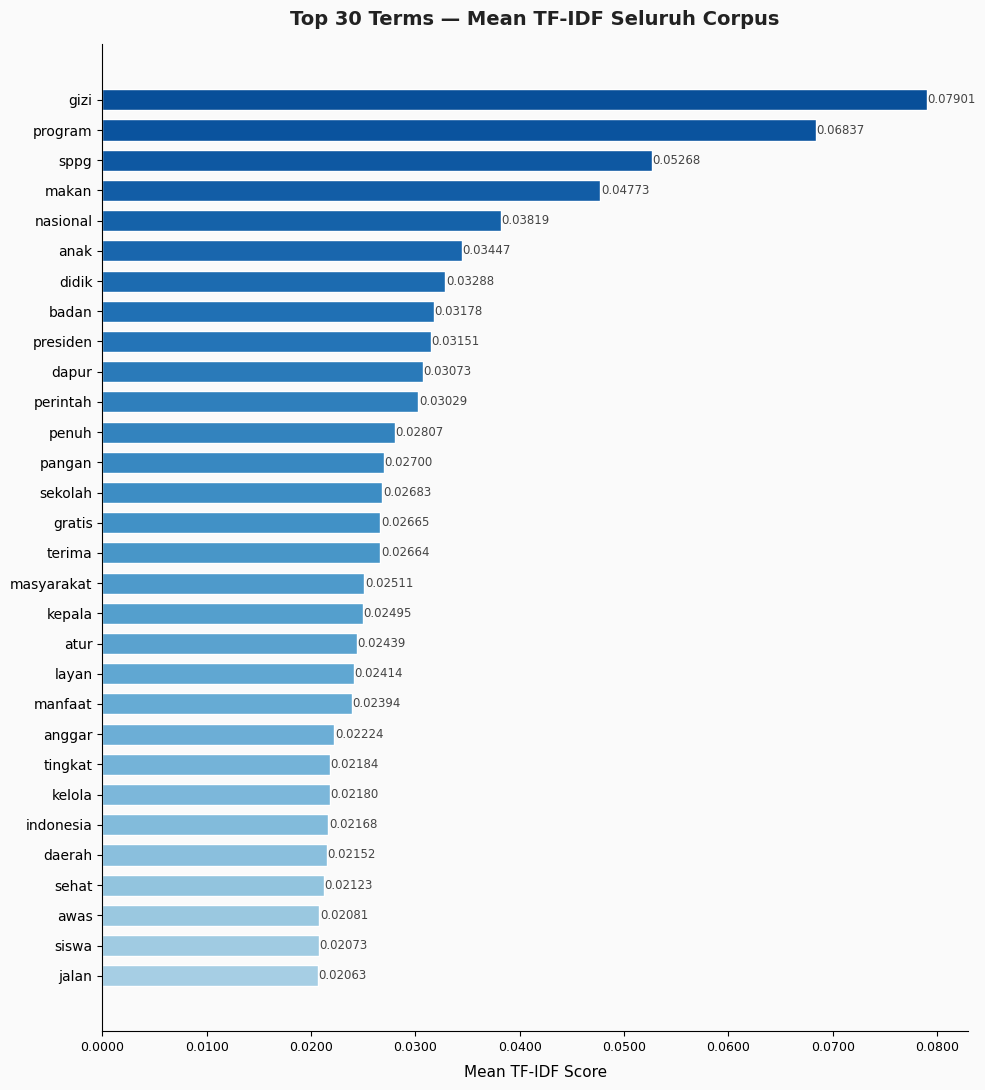

In [59]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

fig, ax = plt.subplots(figsize=(10, 11))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

n = len(top_corpus)
cmap = plt.cm.get_cmap('Blues')
colors = [cmap(0.35 + 0.55 * i / n) for i in range(n)]

bars = ax.barh(
    top_corpus['term'][::-1], top_corpus['mean_tfidf'][::-1],
    color=colors, edgecolor='white', height=0.7
)
for bar, val in zip(bars, top_corpus['mean_tfidf'][::-1]):
    ax.text(
        bar.get_width() + 0.00005,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.5f}', va='center', ha='left', fontsize=8.5, color='#444'
    )

ax.set_xlabel('Mean TF-IDF Score', fontsize=11, labelpad=8)
ax.set_title(
    'Top 30 Terms — Mean TF-IDF Seluruh Corpus',
    fontsize=14, fontweight='bold', pad=14, color='#222'
)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=9)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))
plt.tight_layout()
plt.savefig('output/viz_tfidf_corpus.png', dpi=150, bbox_inches='tight')
plt.show()

In [60]:
# Top word per article (the single most TF-IDF-distinctive word for each article)
top_per_article = []
for i, row in df.iterrows():
    scores = tfidf_corpus[i].toarray().flatten()
    if scores.max() == 0:
        continue
    best_idx = scores.argmax()
    top_per_article.append({
        'judul': row['judul'][:60] + '...' if len(str(row['judul'])) > 60 else row['judul'],
        'sumber': row['sumber'],
        'top_term': features_corpus[best_idx],
        'tfidf': round(float(scores[best_idx]), 4)
    })

df_top_per_article = pd.DataFrame(top_per_article)
print('=== Kata Paling Khas per Artikel (Top TF-IDF Term) ===')
print('\n📊 Cara membaca:')
print('   Setiap baris = satu artikel.')
print('   top_term = kata yang paling MEMBEDAKAN artikel ini dari artikel lain.\n')
display(df_top_per_article)

=== Kata Paling Khas per Artikel (Top TF-IDF Term) ===

📊 Cara membaca:
   Setiap baris = satu artikel.
   top_term = kata yang paling MEMBEDAKAN artikel ini dari artikel lain.



,judul,sumber,top_term,tfidf
0,Andi Gani: Yang Teriak MBG Tak Bermanfaat Depa...,CNN Indonesia,andi,0.4411
1,Konsolidasi Bersama Badan Gizi Nasional dan Gu...,Polri,jambi,0.6680
2,Mengapa Dapur MBG Bisa Beroperasi Tanpa Memenu...,Tempo.co,setop,0.3176
3,"Cerita Sony Sonjaya, Program Makan Bergizi Gra...",JPNN.com,sony,0.5640
4,Sejarah Makan Bergizi Gratis dan Awal Pendiria...,Tribuncirebon.com,antam,0.3315
...,...,...,...,...
703,"Perpres MBG 2025 Resmi Terbit, Pegawai SPPG Be...",RADARSEMARANG.ID,pegawai,0.3716
704,BGN Ancam Bekukan Dapur MBG yang Tolak Bahan d...,Bisnis.com,pasok,0.3307
705,Pegawai SPPG MBG Berpeluang Diangkat Jadi PPPK...,TINTAHIJAU.com,pegawai,0.4763
706,Pemerintah siapkan evaluasi dampak MBG berbasi...,ANTARA News,ukur,0.3298


---
## POS Analysis — Seluruh Corpus

Menggabungkan token POS dari **semua artikel** (tanpa pengelompokan)
untuk melihat kata benda, kata kerja, dan kata sifat yang paling dominan
dalam keseluruhan pemberitaan MBG.

In [61]:
from collections import Counter

# ── NOUN ──────────────────────────────────────────────────────────────────────
all_nouns = ' '.join(df['pos_noun'].fillna('').tolist())
noun_freq = Counter(all_nouns.split())
top_nouns = pd.DataFrame(noun_freq.most_common(30), columns=['kata_benda', 'frekuensi'])
top_nouns.insert(0, 'rank', range(1, len(top_nouns) + 1))

print('=== Top 30 Kata Benda (NOUN) — Seluruh Corpus ===')
print('Kata benda yang paling sering muncul di seluruh artikel MBG:\n')
display(top_nouns)

=== Top 30 Kata Benda (NOUN) — Seluruh Corpus ===
Kata benda yang paling sering muncul di seluruh artikel MBG:



,rank,kata_benda,frekuensi
0,1,gizi,3805
1,2,program,3260
2,3,mbg,2589
3,4,makan,2122
4,5,sppg,2067
5,6,perintah,1265
6,7,badan,1134
7,8,nasional,1080
8,9,presiden,1078
9,10,bgn,1069


In [62]:
# ── VERB ──────────────────────────────────────────────────────────────────────
all_verbs = ' '.join(df['pos_verb'].fillna('').tolist())
verb_freq = Counter(all_verbs.split())
top_verbs = pd.DataFrame(verb_freq.most_common(30), columns=['kata_kerja', 'frekuensi'])
top_verbs.insert(0, 'rank', range(1, len(top_verbs) + 1))

print('=== Top 30 Kata Kerja (VERB) — Seluruh Corpus ===')
print('Aksi/proses yang paling sering dibahas dalam pemberitaan MBG:\n')
display(top_verbs)

=== Top 30 Kata Kerja (VERB) — Seluruh Corpus ===
Aksi/proses yang paling sering dibahas dalam pemberitaan MBG:



,rank,kata_kerja,frekuensi
0,1,jadi,1474
1,2,ada,1118
2,3,laku,853
3,4,jalan,638
4,5,kata,624
5,6,beri,615
6,7,pasti,555
7,8,kait,423
8,9,masuk,420
9,10,ujar,413


In [63]:
# ── ADJ ───────────────────────────────────────────────────────────────────────
all_adjs = ' '.join(df['pos_adj'].fillna('').tolist())
adj_freq = Counter(all_adjs.split())
top_adjs = pd.DataFrame(adj_freq.most_common(30), columns=['kata_sifat', 'frekuensi'])
top_adjs.insert(0, 'rank', range(1, len(top_adjs) + 1))

print('=== Top 30 Kata Sifat (ADJ) — Seluruh Corpus ===')
print('Kata sifat mencerminkan tone/framing pemberitaan MBG:\n')
display(top_adjs)

=== Top 30 Kata Sifat (ADJ) — Seluruh Corpus ===
Kata sifat mencerminkan tone/framing pemberitaan MBG:



,rank,kata_sifat,frekuensi
0,1,nasional,433
1,2,lain,404
2,3,gratis,381
3,4,langsung,362
4,5,operasional,355
5,6,baik,320
6,7,penting,293
7,8,lokal,281
8,9,utama,278
9,10,strategis,276


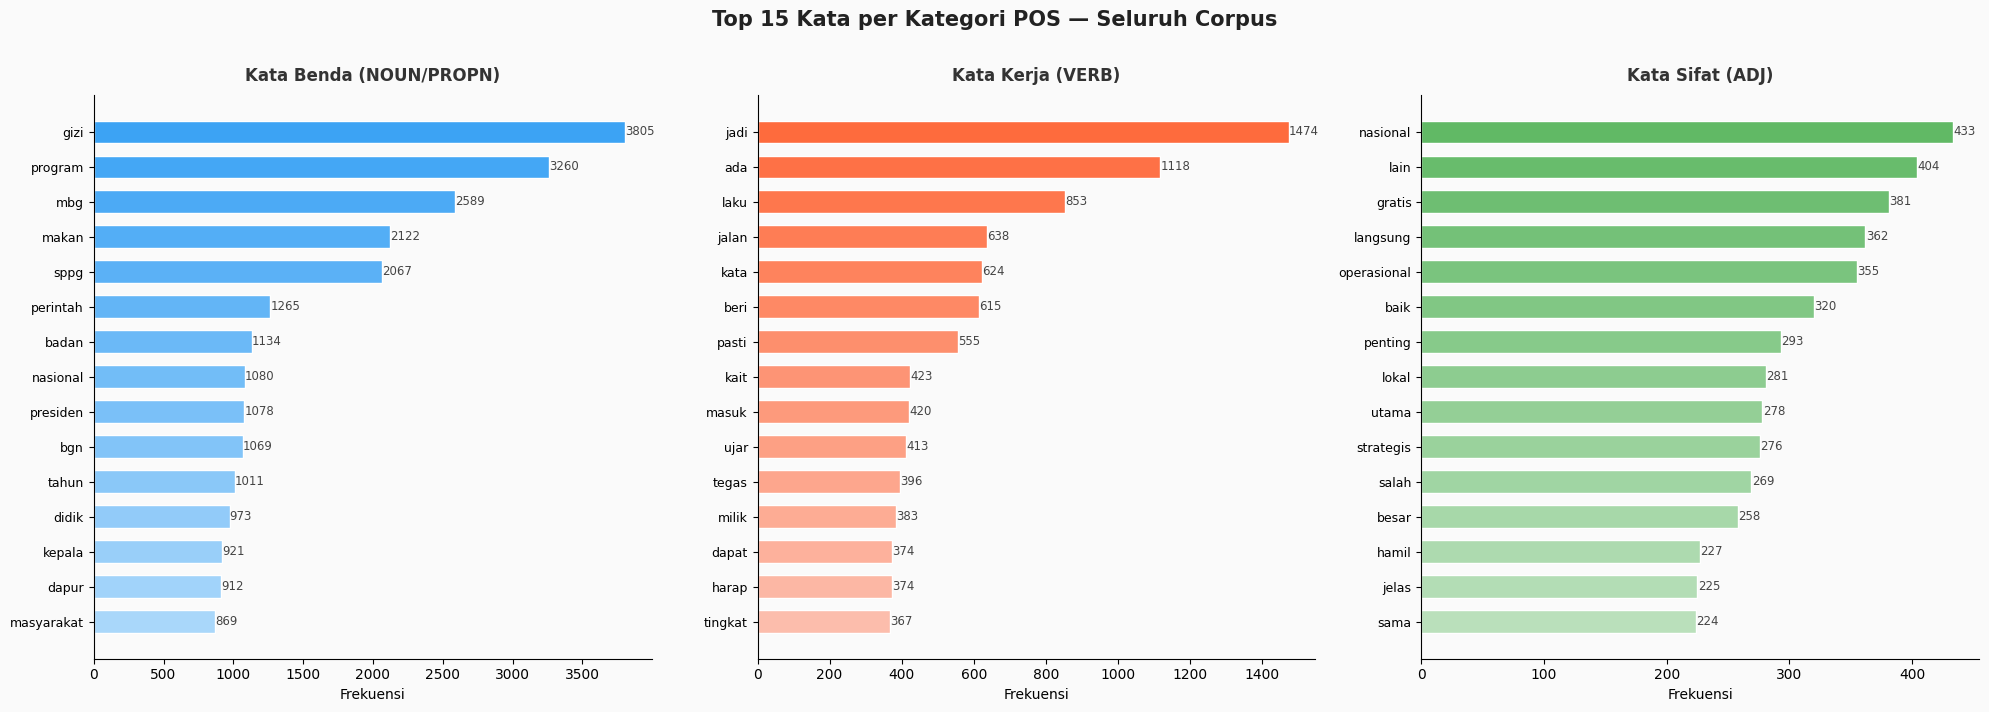

In [64]:
top_n_pos = 15  # how many to show per POS

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle(
    'Top 15 Kata per Kategori POS — Seluruh Corpus',
    fontsize=15, fontweight='bold', y=1.01, color='#222'
)

pos_data = [
    (top_nouns.head(top_n_pos), 'kata_benda',  'Kata Benda (NOUN/PROPN)', '#2196F3'),
    (top_verbs.head(top_n_pos), 'kata_kerja',  'Kata Kerja (VERB)',        '#FF5722'),
    (top_adjs.head(top_n_pos),  'kata_sifat',  'Kata Sifat (ADJ)',         '#4CAF50'),
]

for ax, (df_pos, col, title, base_color) in zip(axes, pos_data):
    ax.set_facecolor('#FAFAFA')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
        'custom', ['#E3F2FD' if base_color == '#2196F3'
                   else '#FBE9E7' if base_color == '#FF5722'
                   else '#E8F5E9', base_color]
    )
    n_bars = len(df_pos)
    bar_colors = [cmap(0.3 + 0.6 * i / n_bars) for i in range(n_bars)]

    bars = ax.barh(
        df_pos[col][::-1], df_pos['frekuensi'][::-1],
        color=bar_colors, edgecolor='white', height=0.65
    )
    for bar, val in zip(bars, df_pos['frekuensi'][::-1].values):
        ax.text(
            bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            str(int(val)), va='center', ha='left', fontsize=8.5, color='#444'
        )
    ax.set_title(title, fontsize=12, fontweight='bold', color='#333', pad=10)
    ax.set_xlabel('Frekuensi', fontsize=10)
    ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('output/viz_pos_corpus.png', dpi=150, bbox_inches='tight')
plt.show()

In [65]:
# TF-IDF on NOUN tokens per article (corpus-wide, not grouped)
noun_texts = df['pos_noun'].fillna('').tolist()
noun_texts_valid = [t for t in noun_texts if t.strip()]

if noun_texts_valid:
    vec_noun = TfidfVectorizer()
    mat_noun = vec_noun.fit_transform(noun_texts)
    feat_noun = vec_noun.get_feature_names_out()
    mean_noun = np.asarray(mat_noun.mean(axis=0)).flatten()
    top_n_idx = mean_noun.argsort()[::-1][:20]
    tfidf_noun_df = pd.DataFrame({
        'rank': range(1, 21),
        'noun_term': feat_noun[top_n_idx],
        'mean_tfidf': mean_noun[top_n_idx].round(5)
    })
    print('=== Top 20 Kata Benda — Mean TF-IDF (corpus-wide) ===')
    display(tfidf_noun_df)

=== Top 20 Kata Benda — Mean TF-IDF (corpus-wide) ===


,rank,noun_term,mean_tfidf
0,1,gizi,0.07722
1,2,program,0.06967
2,3,mbg,0.06321
3,4,sppg,0.05475
4,5,makan,0.04615
5,6,bgn,0.03655
6,7,didik,0.03506
7,8,presiden,0.03349
8,9,badan,0.03324
9,10,perintah,0.03157


---
## NER Analysis — Seluruh Corpus

Menggabungkan semua entitas bernama dari **seluruh artikel** untuk melihat
tokoh, organisasi, dan lokasi yang paling dominan dalam pemberitaan MBG secara keseluruhan.

In [66]:
# ── PER ───────────────────────────────────────────────────────────────────────
all_per = ' '.join(df['ner_per'].fillna('').tolist())
per_freq = Counter(all_per.split())
top_per = pd.DataFrame(per_freq.most_common(20), columns=['tokoh', 'frekuensi'])
top_per['tokoh'] = top_per['tokoh'].str.replace('_', ' ')
top_per.insert(0, 'rank', range(1, len(top_per) + 1))

print('=== Top 20 Tokoh (PER) — Seluruh Corpus ===')
print('Nama orang yang paling sering disebut di seluruh artikel MBG:\n')
display(top_per)

=== Top 20 Tokoh (PER) — Seluruh Corpus ===
Nama orang yang paling sering disebut di seluruh artikel MBG:



,rank,tokoh,frekuensi
0,1,prabowo,77
1,2,prabowo subianto,74
2,3,jokowi,64
3,4,dadan hindayana,63
4,5,dadan,40
5,6,joko widodo,37
6,7,nani,27
7,8,nanik sudaryati deyang,18
8,9,dudung,17
9,10,nanik,17


In [67]:
# ── ORG ───────────────────────────────────────────────────────────────────────
all_org = ' '.join(df['ner_org'].fillna('').tolist())
org_freq = Counter(all_org.split())
top_org = pd.DataFrame(org_freq.most_common(20), columns=['organisasi', 'frekuensi'])
top_org['organisasi'] = top_org['organisasi'].str.replace('_', ' ')
top_org.insert(0, 'rank', range(1, len(top_org) + 1))

print('=== Top 20 Organisasi (ORG) — Seluruh Corpus ===')
print('Lembaga/organisasi yang paling sering disebut dalam pemberitaan MBG:\n')
display(top_org)

=== Top 20 Organisasi (ORG) — Seluruh Corpus ===
Lembaga/organisasi yang paling sering disebut dalam pemberitaan MBG:



,rank,organisasi,frekuensi
0,1,bgn,253
1,2,badan gizi nasional,221
2,3,sppg,149
3,4,g,143
4,5,mbg,115
5,6,satuan pelayanan pemenuhan gizi,111
6,7,spp,79
7,8,gizi nasional,63
8,9,n,49
9,10,kepala,48


In [68]:
# ── LOC ───────────────────────────────────────────────────────────────────────
all_loc = ' '.join(df['ner_loc'].fillna('').tolist())
loc_freq = Counter(all_loc.split())
top_loc = pd.DataFrame(loc_freq.most_common(20), columns=['lokasi', 'frekuensi'])
top_loc['lokasi'] = top_loc['lokasi'].str.replace('_', ' ')
top_loc.insert(0, 'rank', range(1, len(top_loc) + 1))

print('=== Top 20 Lokasi (LOC) — Seluruh Corpus ===')
print('Wilayah/tempat yang paling sering disebut dalam pemberitaan MBG:\n')
display(top_loc)

=== Top 20 Lokasi (LOC) — Seluruh Corpus ===
Wilayah/tempat yang paling sering disebut dalam pemberitaan MBG:



,rank,lokasi,frekuensi
0,1,kantor,8
1,2,spp,8
2,3,dapur,7
3,4,istana negara,7
4,5,istana,6
5,6,monas,4
6,7,ruang pertemuan kalurahan lumbungrejo,4
7,8,cilegon,3
8,9,kompleks parlemen,3
9,10,hotel grand mansion,2


In [69]:
# ── MISC ──────────────────────────────────────────────────────────────────────
all_misc = ' '.join(df['ner_misc'].fillna('').tolist())
misc_freq = Counter(all_misc.split())
top_misc = pd.DataFrame(misc_freq.most_common(20), columns=['misc_entity', 'frekuensi'])
top_misc['misc_entity'] = top_misc['misc_entity'].str.replace('_', ' ')
top_misc.insert(0, 'rank', range(1, len(top_misc) + 1))

print('=== Top 20 MISC — Seluruh Corpus ===')
print('Entitas lain (nama program, undang-undang, istilah teknis):\n')
display(top_misc)

=== Top 20 MISC — Seluruh Corpus ===
Entitas lain (nama program, undang-undang, istilah teknis):



,rank,misc_entity,frekuensi


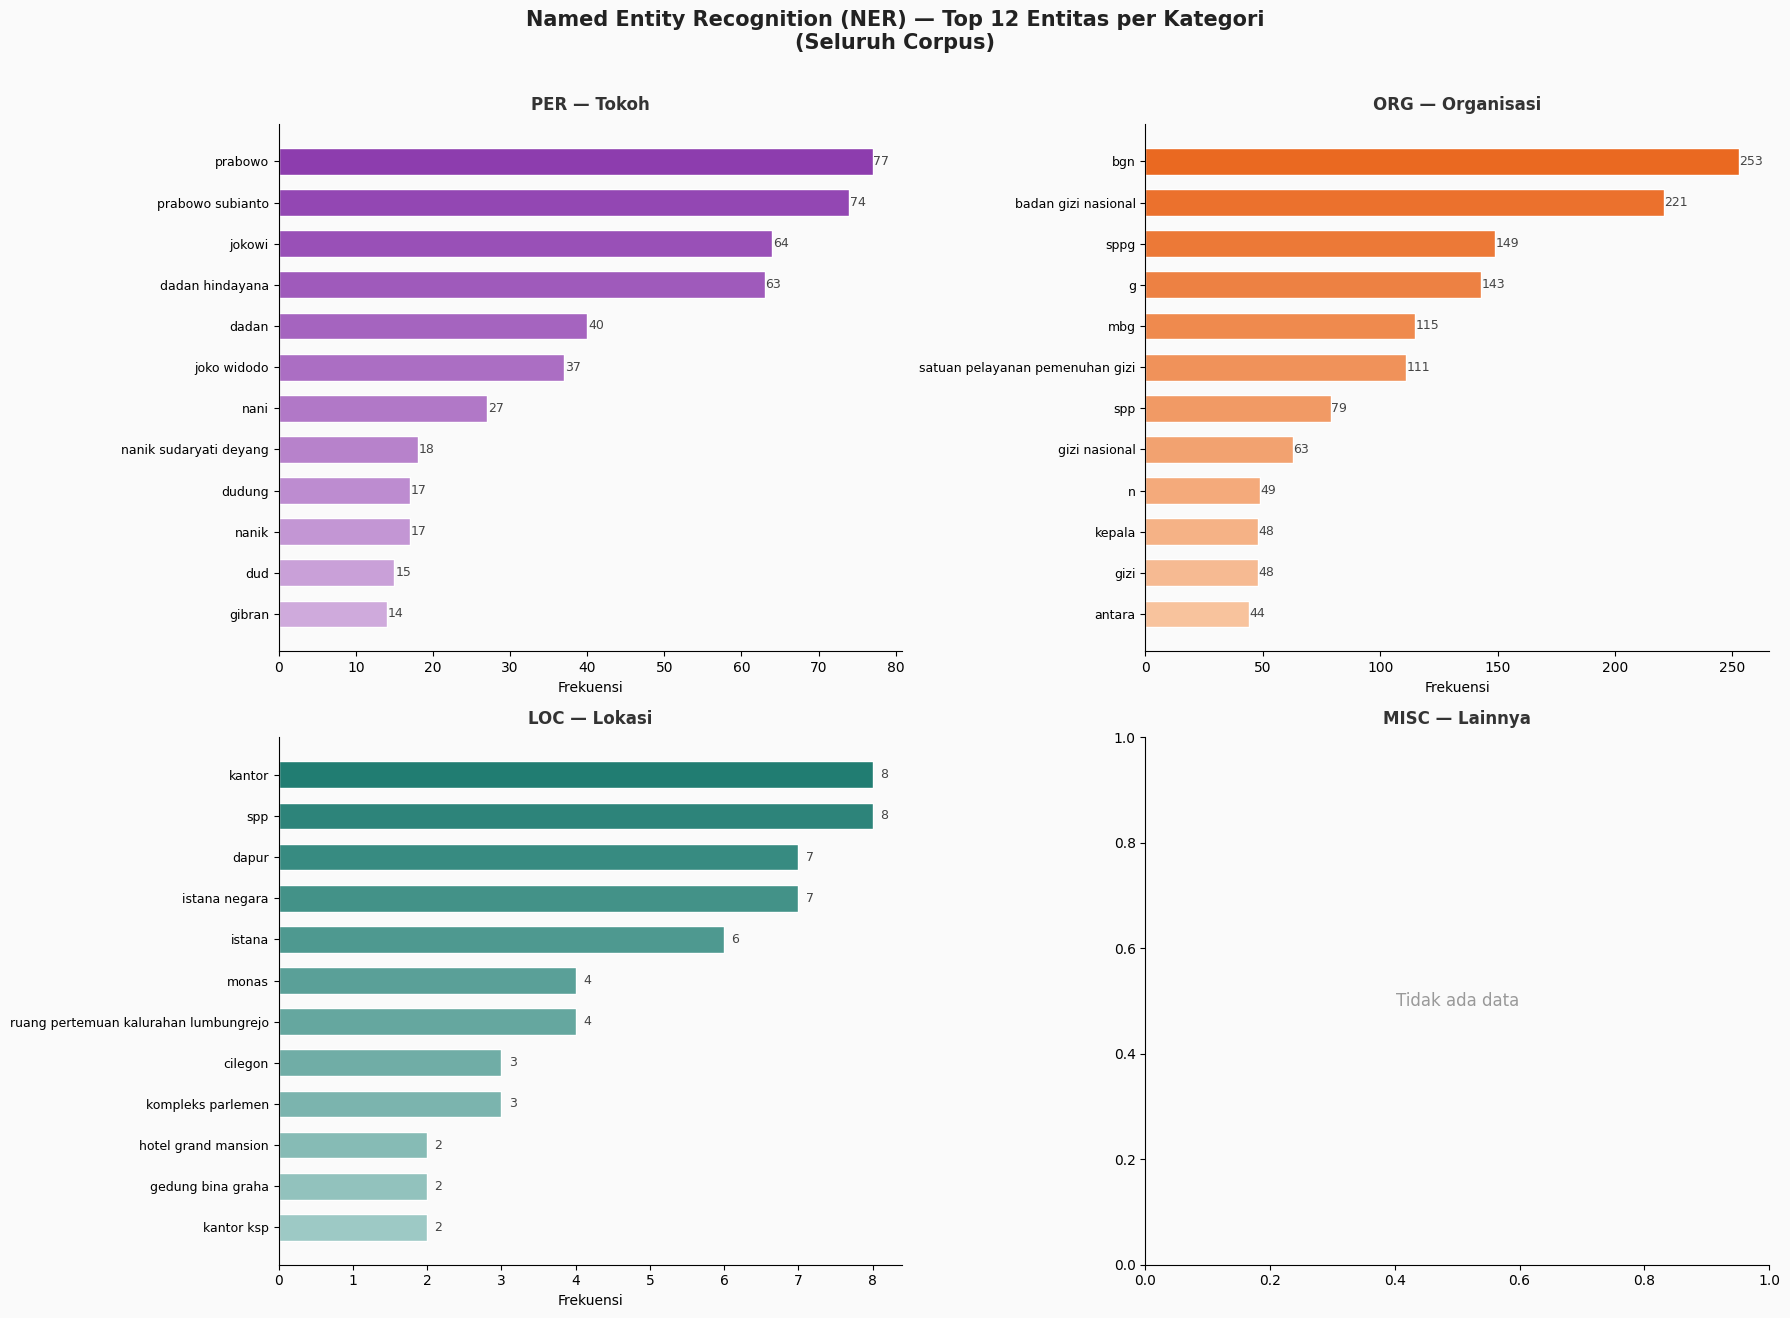

In [70]:
top_n_ner = 12

ner_data = [
    (top_per.head(top_n_ner),  'tokoh',       'PER — Tokoh',        '#7B1FA2', '#F3E5F5'),
    (top_org.head(top_n_ner),  'organisasi',  'ORG — Organisasi',   '#E65100', '#FFF3E0'),
    (top_loc.head(top_n_ner),  'lokasi',      'LOC — Lokasi',       '#00695C', '#E0F2F1'),
    (top_misc.head(top_n_ner), 'misc_entity', 'MISC — Lainnya',     '#1565C0', '#E3F2FD'),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle(
    'Named Entity Recognition (NER) — Top 12 Entitas per Kategori\n(Seluruh Corpus)',
    fontsize=15, fontweight='bold', y=1.01, color='#222'
)
axes_flat = axes.flatten()

for ax, (df_ner, col, title, dark_c, light_c) in zip(axes_flat, ner_data):
    ax.set_facecolor('#FAFAFA')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if df_ner.empty or df_ner['frekuensi'].sum() == 0:
        ax.text(0.5, 0.5, 'Tidak ada data', ha='center', va='center',
                transform=ax.transAxes, fontsize=12, color='#999')
        ax.set_title(title, fontsize=12, fontweight='bold', color='#333', pad=10)
        continue

    cmap_ner = plt.cm.colors.LinearSegmentedColormap.from_list('ner', [light_c, dark_c])
    n_bars = len(df_ner)
    bar_colors = [cmap_ner(0.3 + 0.6 * i / n_bars) for i in range(n_bars)]

    bars = ax.barh(
        df_ner[col][::-1], df_ner['frekuensi'][::-1],
        color=bar_colors, edgecolor='white', height=0.65
    )
    for bar, val in zip(bars, df_ner['frekuensi'][::-1].values):
        ax.text(
            bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            str(int(val)), va='center', ha='left', fontsize=9, color='#444'
        )
    ax.set_title(title, fontsize=12, fontweight='bold', color='#333', pad=10)
    ax.set_xlabel('Frekuensi', fontsize=10)
    ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('output/viz_ner_corpus.png', dpi=150, bbox_inches='tight')
plt.show()

---
## N-Grams — Seluruh Corpus

Mencari **frasa multi-kata** yang paling sering dan paling distingtif
di seluruh corpus artikel MBG, menggunakan Mean TF-IDF corpus-wide.

In [71]:
# ── Bigram corpus-wide ────────────────────────────────────────────────────────
vec_bg = TfidfVectorizer(ngram_range=(2, 2))
mat_bg = vec_bg.fit_transform(df['after_lemmatization'].fillna(''))
feat_bg = vec_bg.get_feature_names_out()
mean_bg = np.asarray(mat_bg.mean(axis=0)).flatten()
top_bg_idx = mean_bg.argsort()[::-1][:25]

top_bigram_corpus = pd.DataFrame({
    'rank': range(1, 26),
    'bigram': feat_bg[top_bg_idx],
    'mean_tfidf': mean_bg[top_bg_idx].round(5)
})

print('=== Top 25 Bigram — Mean TF-IDF Seluruh Corpus ===')
print('Frasa 2 kata yang paling distingtif di keseluruhan corpus:\n')
display(top_bigram_corpus)

=== Top 25 Bigram — Mean TF-IDF Seluruh Corpus ===
Frasa 2 kata yang paling distingtif di keseluruhan corpus:



,rank,bigram,mean_tfidf
0,1,gizi nasional,0.02629
1,2,makan gizi,0.02263
2,3,badan gizi,0.02227
3,4,gizi gratis,0.02007
4,5,program makan,0.01754
5,6,penuh gizi,0.01731
6,7,terima manfaat,0.01446
7,8,layan penuh,0.01122
8,9,anak anak,0.01080
9,10,gizi sppg,0.01020


In [72]:
# ── Trigram corpus-wide ───────────────────────────────────────────────────────
vec_tg = TfidfVectorizer(ngram_range=(3, 3))
mat_tg = vec_tg.fit_transform(df['after_lemmatization'].fillna(''))
feat_tg = vec_tg.get_feature_names_out()
mean_tg = np.asarray(mat_tg.mean(axis=0)).flatten()
top_tg_idx = mean_tg.argsort()[::-1][:25]

top_trigram_corpus = pd.DataFrame({
    'rank': range(1, 26),
    'trigram': feat_tg[top_tg_idx],
    'mean_tfidf': mean_tg[top_tg_idx].round(5)
})

print('=== Top 25 Trigram — Mean TF-IDF Seluruh Corpus ===')
print('Frasa 3 kata yang paling distingtif di keseluruhan corpus:\n')
display(top_trigram_corpus)

=== Top 25 Trigram — Mean TF-IDF Seluruh Corpus ===
Frasa 3 kata yang paling distingtif di keseluruhan corpus:



,rank,trigram,mean_tfidf
0,1,badan gizi nasional,0.02105
1,2,makan gizi gratis,0.01917
2,3,program makan gizi,0.01544
3,4,layan penuh gizi,0.01089
4,5,penuh gizi sppg,0.00957
5,6,penuh gizi nasional,0.00712
6,7,kepala badan gizi,0.00696
7,8,presiden prabowo subianto,0.00512
8,9,atur presiden pres,0.00489
9,10,makan siang gratis,0.00484


In [73]:
# ── Raw frequency of bigrams (tanpa TF-IDF weighting) ────────────────────────
from sklearn.feature_extraction.text import CountVectorizer

cv_bg = CountVectorizer(ngram_range=(2, 2))
count_mat = cv_bg.fit_transform(df['after_lemmatization'].fillna(''))
count_feat = cv_bg.get_feature_names_out()
total_counts = np.asarray(count_mat.sum(axis=0)).flatten()
top_count_idx = total_counts.argsort()[::-1][:25]

top_bigram_freq = pd.DataFrame({
    'rank': range(1, 26),
    'bigram': count_feat[top_count_idx],
    'frekuensi': total_counts[top_count_idx]
})

print('=== Top 25 Bigram — Frekuensi Murni (Count) Seluruh Corpus ===')
print('\n📊 Perbedaan vs TF-IDF:')
print('   Count = frekuensi mentah, tidak mempertimbangkan seberapa umum frasa itu')
print('   TF-IDF = mempertimbangkan keunikan frasa antar artikel\n')
display(top_bigram_freq)

=== Top 25 Bigram — Frekuensi Murni (Count) Seluruh Corpus ===

📊 Perbedaan vs TF-IDF:
   Count = frekuensi mentah, tidak mempertimbangkan seberapa umum frasa itu
   TF-IDF = mempertimbangkan keunikan frasa antar artikel



,rank,bigram,frekuensi
0,1,makan gizi,1393
1,2,gizi gratis,1228
2,3,gizi nasional,1184
3,4,badan gizi,984
4,5,program makan,965
5,6,penuh gizi,857
6,7,batal pinjam,801
7,8,spinjam shopee,620
8,9,shopee pinjam,619
9,10,terima manfaat,534


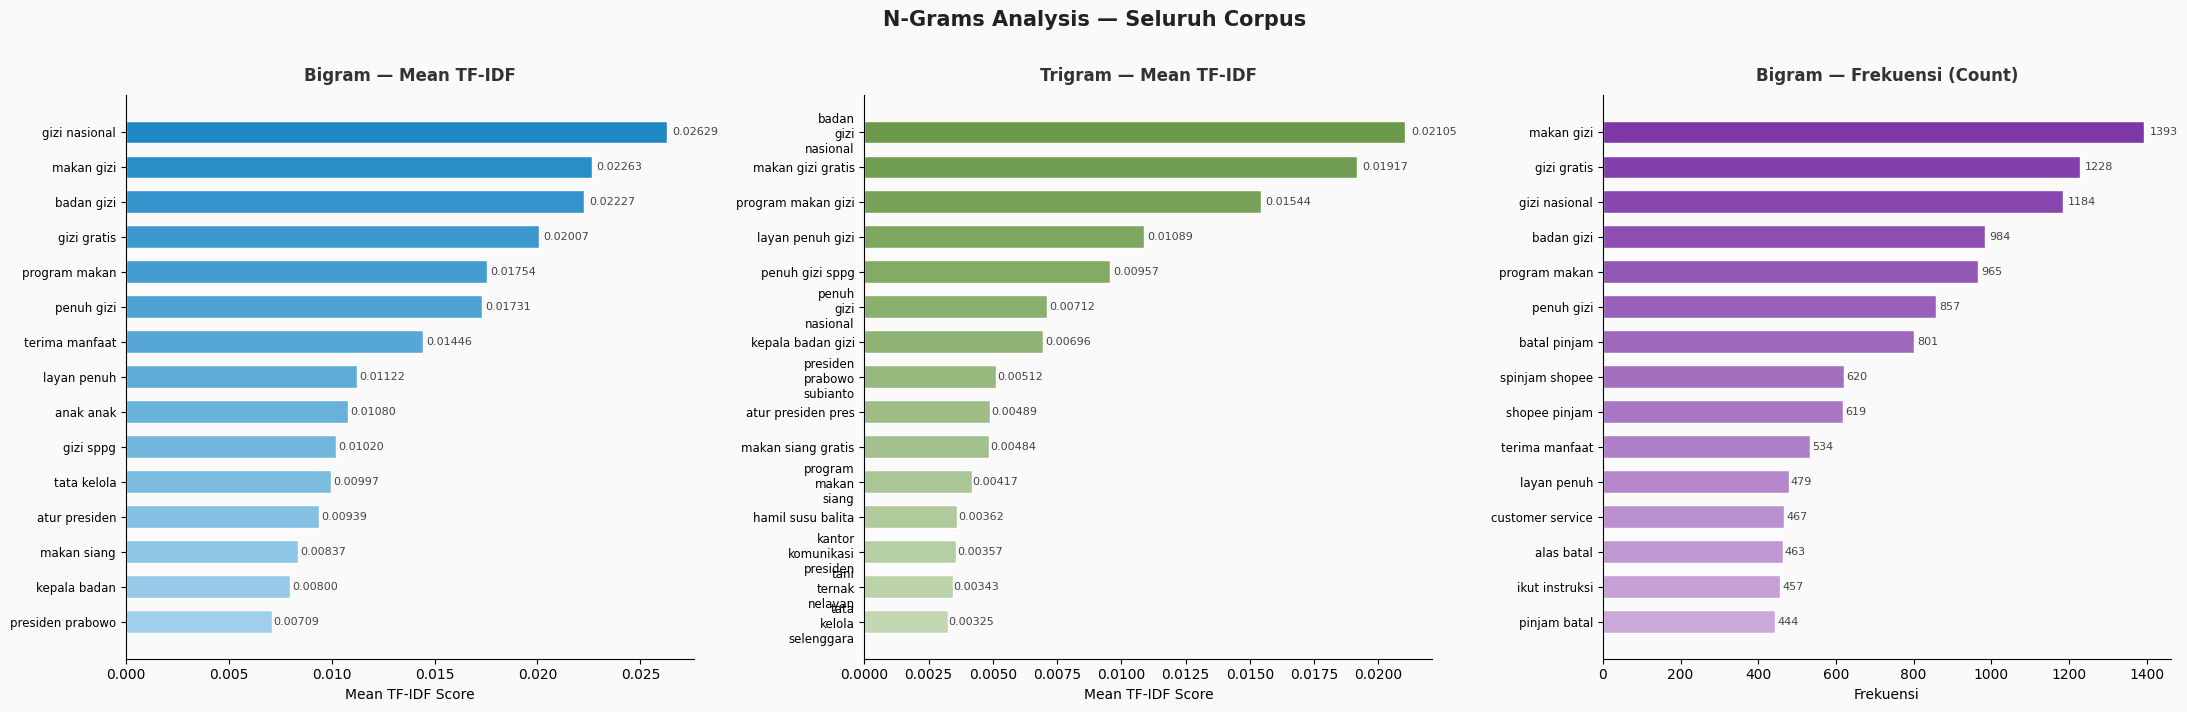

In [74]:
top_n_ng = 15

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle(
    'N-Grams Analysis — Seluruh Corpus',
    fontsize=15, fontweight='bold', y=1.01, color='#222'
)

ng_data = [
    (top_bigram_corpus.head(top_n_ng),  'bigram',  'mean_tfidf',
     'Bigram — Mean TF-IDF',   '#0277BD', '#E1F5FE'),
    (top_trigram_corpus.head(top_n_ng), 'trigram', 'mean_tfidf',
     'Trigram — Mean TF-IDF',  '#558B2F', '#F1F8E9'),
    (top_bigram_freq.head(top_n_ng),    'bigram',  'frekuensi',
     'Bigram — Frekuensi (Count)', '#6A1B9A', '#F3E5F5'),
]

for ax, (df_ng, term_col, val_col, title, dark_c, light_c) in zip(axes, ng_data):
    ax.set_facecolor('#FAFAFA')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    cmap_ng = plt.cm.colors.LinearSegmentedColormap.from_list('ng', [light_c, dark_c])
    n_bars = len(df_ng)
    bar_colors = [cmap_ng(0.3 + 0.6 * i / n_bars) for i in range(n_bars)]

    # Wrap long n-gram labels
    labels = [t.replace(' ', '\n') if len(t) > 18 else t
              for t in df_ng[term_col][::-1]]

    bars = ax.barh(
        labels, df_ng[val_col][::-1].values,
        color=bar_colors, edgecolor='white', height=0.65
    )
    for bar, val in zip(bars, df_ng[val_col][::-1].values):
        label = f'{val:.5f}' if val < 1 else str(int(val))
        ax.text(
            bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
            label, va='center', ha='left', fontsize=8, color='#444'
        )
    ax.set_title(title, fontsize=12, fontweight='bold', color='#333', pad=10)
    x_label = 'Mean TF-IDF Score' if val_col == 'mean_tfidf' else 'Frekuensi'
    ax.set_xlabel(x_label, fontsize=10)
    ax.tick_params(axis='y', labelsize=8.5)

plt.tight_layout()
plt.savefig('output/viz_ngram_corpus.png', dpi=150, bbox_inches='tight')
plt.show()